In [1]:
# Imports, seeds, config
# Baseline thesis model:
# - node = asset
# - spatiotemporal graph forecasting in Graph WaveNet / MTGNN spirit
# - fixed physical forecast horizon = 5 real-time minutes for every frequency
# - leakage-safe preprocessing, splitting, scaling, and threshold selection
# - no online learning, no memory modules, no multigraph fusion

from __future__ import annotations

import json
import math
import os
import random
import warnings
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

EPS = 1e-12


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, (os.cpu_count() or 4) - 1))
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

CFG: Dict[str, Any] = {
    # -----------------------------
    # Data / files
    # -----------------------------
    "data_dir": "../dataset",
    "file_template": "{asset}_{freq}.csv",
    "assets": ["ADA", "BTC", "ETH"],
    "target_asset": "ETH",
    "freq": "1min",  # supported here: 1s / 1min / 5min
    "timestamp_col": "system_time",
    "price_col": "midpoint",
    "spread_col": "spread",
    "buys_col": "buys",
    "sells_col": "sells",
    "book_levels": 15,
    "top_levels": 5,
    "near_levels": 5,

    # -----------------------------
    # Regular-grid alignment
    # -----------------------------
    # The panel uses the common time span across all assets.
    # Missing grid bars are repaired with past-only operations:
    # - snapshot-like values: forward-fill
    # - flow values: zero-fill
    "panel_common_time_span": "intersection",  # "intersection" or "union"
    "normalize_panel_to_regular_grid": True,
    "optional_resample_before_join": True,
    "resample_rule_override": None,

    # -----------------------------
    # Real-time problem definition
    # -----------------------------
    # All primary windows are defined in real time first.
    # They are converted to bars exactly for the selected frequency.
    "forecast_horizon_minutes": 5,
    "lookback_minutes": 60,
    "label_vol_lookback_minutes": 60,
    "corr_windows_minutes": [5, 15, 30, 60],
    "feature_vol_windows_minutes": [5, 30],
    "lead_lag_seconds": [0, 60, 120, 300],

    # -----------------------------
    # Minimum observation rules for rolling statistics
    # -----------------------------
    # We do NOT inflate underspecified real-time windows with arbitrary bar floors.
    # Instead, windows that become too short in bars for a statistic are dropped.
    # This preserves physical comparability across frequencies.
    "min_corr_window_bars": 3,
    "min_beta_window_bars": 3,
    "min_vol_window_bars": 2,

    # -----------------------------
    # Labels
    # -----------------------------
    # y_ret   = future H-bar log return over the next 5 real-time minutes
    # y_trade = 1{|y_ret| > past-only volatility threshold}
    # y_dir   = 1{y_ret > 0}
    "trade_threshold_vol_mult": 1.25,
    "trade_threshold_min_abs_return": 0.0,
    "trade_threshold_max_abs_return": None,

    # -----------------------------
    # Splits
    # -----------------------------
    "holdout_frac": 0.10,
    "cv_train_min_frac": 0.50,
    "cv_val_frac": 0.10,
    "cv_test_frac": 0.10,
    "cv_step_frac": 0.08,
    "min_samples_per_block": 64,

    # -----------------------------
    # Scaling
    # -----------------------------
    # Scalers are fit on training bars only.
    "robust_quantile_range": (5.0, 95.0),
    "max_abs_node_feature": 8.0,
    "max_abs_edge_feature": 6.0,

    # -----------------------------
    # Graph supports
    # -----------------------------
    "use_static_support": True,
    "use_prior_support": True,
    "use_adaptive_support": True,
    "static_adj_mode": "identity",  # "identity" or "uniform_complete"
    "prior_mlp_hidden_dim": 32,
    "prior_diag_boost": 1.0,
    "prior_row_normalize": True,
    "adaptive_adj_emb_dim": 12,
    "adaptive_adj_temperature": 1.0,
    "adaptive_adj_topk": None,

    # -----------------------------
    # Temporal model
    # -----------------------------
    # Exact-coverage causal dilation schedule:
    # with kernel size = 2, receptive field = 1 + sum(dilations)
    # and we choose dilations so that receptive field matches lookback exactly.
    # This directly fixes the "nominal long lookback / tiny effective RF" problem.
    "temporal_kernel_size": 2,
    "residual_channels": 32,
    "dilation_channels": 32,
    "skip_channels": 64,
    "end_channels": 64,
    "dropout": 0.15,

    # -----------------------------
    # Training
    # -----------------------------
    "batch_size": None,  # if None, inferred from lookback bars
    "epochs": 35,
    "lr": 2e-4,
    "weight_decay": 1e-3,
    "grad_clip": 1.0,
    "early_stopping_patience": 8,
    "num_workers": 0,

    # -----------------------------
    # Loss
    # -----------------------------
    "loss_w_trade": 1.0,
    "loss_w_dir": 0.8,
    "loss_w_ret": 0.5,
    "ret_huber_delta": 0.003,
    "adj_l1_lambda": 1e-4,
    "adj_prior_lambda": 5e-4,

    # -----------------------------
    # Threshold selection
    # -----------------------------
    # Thresholds are chosen on validation only and then frozen.
    "thr_trade_grid": [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80],
    "thr_dir_grid": [0.50, 0.55, 0.60, 0.65, 0.70],
    "min_val_trades_for_selection": 20,

    # -----------------------------
    # Diagnostic backtest
    # -----------------------------
    # Simplified diagnostic only, not a production execution simulator.
    "fee_bps_one_way": 1.0,
    "allow_reentry_same_exit_bar": False,

    # -----------------------------
    # Artifacts / plots
    # -----------------------------
    "artifact_dir": "./artifacts_stg_baseline_fixed5m_exactrf",
    "save_predictions": True,
    "plot_equity_curve": True,
    "plot_trade_calibration": True,
    "plot_adaptive_adjacency": True,
}

ASSETS: List[str] = list(CFG["assets"])
ASSET2IDX: Dict[str, int] = {a: i for i, a in enumerate(ASSETS)}
TARGET_ASSET: str = str(CFG["target_asset"])
if TARGET_ASSET not in ASSET2IDX:
    raise KeyError(f"target_asset='{TARGET_ASSET}' is not in assets={ASSETS}")
TARGET_NODE: int = ASSET2IDX[TARGET_ASSET]

ART_DIR = Path(CFG["artifact_dir"])
ART_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("Assets:", ASSETS)
print("Target asset:", TARGET_ASSET)
print("Artifact dir:", ART_DIR.resolve())



DEVICE: cpu
Assets: ['ADA', 'BTC', 'ETH']
Target asset: ETH
Artifact dir: /Users/vitalii/Desktop/Model_Market_Microstructure/Graph_Neural_Network_for_Market_Microstructure/TGNN2026/artifacts_stg_baseline_fixed5m_exactrf


In [2]:
# Frequency conversion and exact receptive-field design

def parse_freq_to_timedelta(freq: str) -> pd.Timedelta:
    key = str(freq).lower()
    mapping = {
        "1s": pd.Timedelta(seconds=1),
        "1sec": pd.Timedelta(seconds=1),
        "1second": pd.Timedelta(seconds=1),
        "1m": pd.Timedelta(minutes=1),
        "1min": pd.Timedelta(minutes=1),
        "5m": pd.Timedelta(minutes=5),
        "5min": pd.Timedelta(minutes=5),
    }
    if key in mapping:
        return mapping[key]
    return pd.to_timedelta(freq)


def bars_from_minutes_exact(minutes: float, bar_td: pd.Timedelta) -> int:
    if minutes <= 0:
        return 0
    return int(math.ceil(pd.Timedelta(minutes=float(minutes)) / bar_td))


def bars_from_seconds_resolved(seconds: float, bar_td: pd.Timedelta) -> Optional[int]:
    """
    For feature lags, we do NOT coerce unresolved sub-bar lags upward.
    If the requested lag is smaller than one bar, or not an exact integer multiple
    of the bar size, it is dropped as unresolvable at this frequency.
    """
    if seconds < 0:
        raise ValueError("Lag seconds must be nonnegative")
    if seconds == 0:
        return 0
    bar_seconds = bar_td.total_seconds()
    ratio = float(seconds) / float(bar_seconds)
    rounded = int(round(ratio))
    if rounded < 1:
        return None
    if not math.isclose(ratio, rounded, rel_tol=0.0, abs_tol=1e-9):
        return None
    return rounded


def unique_sorted_ints(values: Iterable[int]) -> List[int]:
    return sorted({int(v) for v in values})


def filter_windows_by_stat_requirement(
    window_bars: Sequence[int],
    min_required_bars: int,
    label: str,
) -> Tuple[List[int], List[int]]:
    valid = unique_sorted_ints([w for w in window_bars if int(w) >= int(min_required_bars)])
    dropped = unique_sorted_ints([w for w in window_bars if int(w) < int(min_required_bars)])
    if dropped:
        print(f"[INFO] Dropped {label} windows (too short in bars for this frequency): {dropped}")
    return valid, dropped


def build_exact_cover_dilations(lookback_bars: int, kernel_size: int) -> List[int]:
    """
    For kernel size 2, receptive field is:
        RF = 1 + sum(dilations)
    We construct a greedy ascending schedule that exactly covers the lookback.
    This removes the old mismatch between nominal lookback and effective RF.
    """
    if int(kernel_size) != 2:
        raise ValueError("This exact-coverage schedule is implemented for kernel_size=2 only.")
    if int(lookback_bars) < 2:
        raise ValueError("lookback_bars must be at least 2")

    remaining = int(lookback_bars) - 1
    dilations: List[int] = []
    d = 1
    while remaining > 0:
        if d < remaining:
            dilations.append(d)
            remaining -= d
            d *= 2
        else:
            dilations.append(remaining)
            remaining = 0
    return dilations


def compute_receptive_field(kernel_size: int, dilations: Sequence[int]) -> int:
    rf = 1
    for d in dilations:
        rf += (int(kernel_size) - 1) * int(d)
    return rf


def infer_batch_size(lookback_bars: int, user_batch_size: Optional[int]) -> int:
    if user_batch_size is not None:
        return int(user_batch_size)
    if lookback_bars >= 1800:
        return 8
    if lookback_bars >= 600:
        return 16
    if lookback_bars >= 120:
        return 32
    return 64


BAR_TD = parse_freq_to_timedelta(CFG["freq"])
BAR_SECONDS = BAR_TD.total_seconds()

corr_window_bars_raw = [bars_from_minutes_exact(m, BAR_TD) for m in CFG["corr_windows_minutes"]]
feature_vol_window_bars_raw = [bars_from_minutes_exact(m, BAR_TD) for m in CFG["feature_vol_windows_minutes"]]

lead_lag_bars_raw: List[int] = []
dropped_lead_lags_seconds: List[float] = []
for sec in CFG["lead_lag_seconds"]:
    lag_bars = bars_from_seconds_resolved(sec, BAR_TD)
    if lag_bars is None:
        dropped_lead_lags_seconds.append(float(sec))
    else:
        lead_lag_bars_raw.append(int(lag_bars))
if dropped_lead_lags_seconds:
    print(
        "[INFO] Dropped unresolved lead-lag values in seconds "
        f"(sub-bar or non-integer-bar at this frequency): {dropped_lead_lags_seconds}"
    )

corr_window_bars, dropped_corr_window_bars = filter_windows_by_stat_requirement(
    corr_window_bars_raw,
    min_required_bars=int(CFG["min_corr_window_bars"]),
    label="correlation/beta",
)
feature_vol_window_bars, dropped_feature_vol_window_bars = filter_windows_by_stat_requirement(
    feature_vol_window_bars_raw,
    min_required_bars=int(CFG["min_vol_window_bars"]),
    label="feature-volatility",
)
lead_lag_bars = unique_sorted_ints(lead_lag_bars_raw)

LOOKBACK_BARS = bars_from_minutes_exact(CFG["lookback_minutes"], BAR_TD)
HORIZON_BARS = bars_from_minutes_exact(CFG["forecast_horizon_minutes"], BAR_TD)
LABEL_VOL_LOOKBACK_BARS = bars_from_minutes_exact(CFG["label_vol_lookback_minutes"], BAR_TD)
PURGE_GAP_BARS = int(HORIZON_BARS)

if LOOKBACK_BARS < 2:
    raise ValueError("Lookback must resolve to at least 2 bars.")
if HORIZON_BARS < 1:
    raise ValueError("Forecast horizon must resolve to at least 1 bar.")
if LABEL_VOL_LOOKBACK_BARS < 2:
    raise ValueError("Label volatility lookback must resolve to at least 2 bars.")
if not corr_window_bars:
    raise ValueError("No valid correlation/beta windows remain at this frequency.")
if not feature_vol_window_bars:
    raise ValueError("No valid feature-volatility windows remain at this frequency.")

TEMPORAL_DILATIONS = build_exact_cover_dilations(
    lookback_bars=LOOKBACK_BARS,
    kernel_size=int(CFG["temporal_kernel_size"]),
)
RECEPTIVE_FIELD_BARS = compute_receptive_field(
    kernel_size=int(CFG["temporal_kernel_size"]),
    dilations=TEMPORAL_DILATIONS,
)
if RECEPTIVE_FIELD_BARS != LOOKBACK_BARS:
    raise AssertionError("Receptive field must match lookback exactly in this baseline.")

CFG["batch_size"] = infer_batch_size(LOOKBACK_BARS, CFG["batch_size"])

DERIVED: Dict[str, Any] = {
    "bar_timedelta": str(BAR_TD),
    "bar_seconds": BAR_SECONDS,
    "forecast_horizon_bars": HORIZON_BARS,
    "lookback_bars": LOOKBACK_BARS,
    "label_vol_lookback_bars": LABEL_VOL_LOOKBACK_BARS,
    "corr_window_bars": corr_window_bars,
    "feature_vol_window_bars": feature_vol_window_bars,
    "lead_lag_bars": lead_lag_bars,
    "dropped_corr_window_bars": dropped_corr_window_bars,
    "dropped_feature_vol_window_bars": dropped_feature_vol_window_bars,
    "dropped_lead_lag_seconds": dropped_lead_lags_seconds,
    "purge_gap_bars": PURGE_GAP_BARS,
    "temporal_dilations": TEMPORAL_DILATIONS,
    "receptive_field_bars": RECEPTIVE_FIELD_BARS,
    "effective_temporal_layers": len(TEMPORAL_DILATIONS),
    "batch_size_effective": int(CFG["batch_size"]),
}

print("\nDerived setup")
print(json.dumps(DERIVED, indent=2))




Derived setup
{
  "bar_timedelta": "0 days 00:01:00",
  "bar_seconds": 60.0,
  "forecast_horizon_bars": 5,
  "lookback_bars": 60,
  "label_vol_lookback_bars": 60,
  "corr_window_bars": [
    5,
    15,
    30,
    60
  ],
  "feature_vol_window_bars": [
    5,
    30
  ],
  "lead_lag_bars": [
    0,
    1,
    2,
    5
  ],
  "dropped_corr_window_bars": [],
  "dropped_feature_vol_window_bars": [],
  "dropped_lead_lag_seconds": [],
  "purge_gap_bars": 5,
  "temporal_dilations": [
    1,
    2,
    4,
    8,
    16,
    28
  ],
  "receptive_field_bars": 60,
  "effective_temporal_layers": 6,
  "batch_size_effective": 64
}


In [3]:
# Data loading helpers

def ensure_utc_timestamp(ts: pd.Series) -> pd.Series:
    return pd.to_datetime(ts, utc=True, errors="coerce")


def find_book_column(df: pd.DataFrame, side_prefix: str, level: int) -> str:
    candidates = [
        f"{side_prefix}_notional_{level}",
        f"{side_prefix}_vol_{level}",
        f"{side_prefix}_volume_{level}",
        f"{side_prefix}_{level}",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Missing order-book column for {side_prefix} level {level}. Tried {candidates}"
    )


def load_one_asset_raw(asset: str, cfg: Dict[str, Any]) -> pd.DataFrame:
    path = Path(cfg["data_dir"]) / cfg["file_template"].format(asset=asset, freq=cfg["freq"])
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    part = (0.0, 0.75)
    df = pd.read_csv(path)
    start = int(len(df) * float(part[0]))
    end = int(len(df) * float(part[1]))
    df = df.iloc[start:end]
    if cfg["timestamp_col"] not in df.columns:
        raise KeyError(f"{asset}: missing timestamp column '{cfg['timestamp_col']}'")

    required_base = [cfg["price_col"], cfg["spread_col"], cfg["buys_col"], cfg["sells_col"]]
    missing_base = [c for c in required_base if c not in df.columns]
    if missing_base:
        raise KeyError(f"{asset}: missing required columns {missing_base}")

    bid_cols = [find_book_column(df, "bids", i) for i in range(int(cfg["book_levels"]))]
    ask_cols = [find_book_column(df, "asks", i) for i in range(int(cfg["book_levels"]))]

    keep_cols = [cfg["timestamp_col"]] + required_base + bid_cols + ask_cols
    df = df[keep_cols].copy()

    df["timestamp"] = ensure_utc_timestamp(df[cfg["timestamp_col"]])
    if df["timestamp"].isna().any():
        bad = int(df["timestamp"].isna().sum())
        raise ValueError(f"{asset}: {bad} timestamps could not be parsed")

    df = df.drop(columns=[cfg["timestamp_col"]]).sort_values("timestamp").reset_index(drop=True)
    if df["timestamp"].duplicated().any():
        dup = int(df["timestamp"].duplicated().sum())
        print(f"[WARN] {asset}: found {dup} duplicate timestamps; keeping last occurrence")
        df = df.drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    rename_map = {
        cfg["price_col"]: f"mid_{asset}",
        cfg["spread_col"]: f"spread_{asset}",
        cfg["buys_col"]: f"buys_{asset}",
        cfg["sells_col"]: f"sells_{asset}",
    }
    for i, c in enumerate(bid_cols):
        rename_map[c] = f"bids_depth_{asset}_{i}"
    for i, c in enumerate(ask_cols):
        rename_map[c] = f"asks_depth_{asset}_{i}"

    return df.rename(columns=rename_map)


def resample_one_asset(df: pd.DataFrame, asset: str, rule: str, cfg: Dict[str, Any]) -> pd.DataFrame:
    value_cols_last = [f"mid_{asset}", f"spread_{asset}"]
    value_cols_sum = [f"buys_{asset}", f"sells_{asset}"]
    depth_cols_last = [f"bids_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))] + [
        f"asks_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))
    ]

    work = df.set_index("timestamp").sort_index()
    agg_spec = {c: "last" for c in value_cols_last + depth_cols_last}
    agg_spec.update({c: "sum" for c in value_cols_sum})

    out = (
        work.resample(rule, label="right", closed="right")
        .agg(agg_spec)
        .dropna(how="all")
        .reset_index()
    )
    return out


def describe_time_grid(asset: str, df: pd.DataFrame, bar_td: pd.Timedelta) -> None:
    ts = df["timestamp"].sort_values()
    if len(ts) < 2:
        print(f"{asset}: too few rows")
        return
    diffs = ts.diff().dropna()
    modal_step = diffs.mode().iloc[0] if not diffs.mode().empty else diffs.iloc[0]
    print(
        f"{asset}: rows={len(df)} | range={ts.iloc[0]} -> {ts.iloc[-1]} | "
        f"median_step={diffs.median()} | modal_step={modal_step}"
    )


def get_snapshot_and_flow_columns(cfg: Dict[str, Any], assets: Sequence[str]) -> Tuple[List[str], List[str]]:
    flow_cols: List[str] = []
    snap_cols: List[str] = []
    for asset in assets:
        flow_cols.extend([f"buys_{asset}", f"sells_{asset}"])
        snap_cols.extend([f"mid_{asset}", f"spread_{asset}"])
        snap_cols.extend([f"bids_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))])
        snap_cols.extend([f"asks_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))])
    return snap_cols, flow_cols


raw_asset_frames: Dict[str, pd.DataFrame] = {a: load_one_asset_raw(a, CFG) for a in ASSETS}
for asset, frame in raw_asset_frames.items():
    if bool(CFG["optional_resample_before_join"]):
        rule = CFG["resample_rule_override"] or CFG["freq"]
        raw_asset_frames[asset] = resample_one_asset(frame, asset=asset, rule=rule, cfg=CFG)
    describe_time_grid(asset, raw_asset_frames[asset], BAR_TD)



ADA: rows=12882 | range=2021-04-07 11:34:00+00:00 -> 2021-04-16 10:15:00+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00
BTC: rows=12886 | range=2021-04-07 11:34:00+00:00 -> 2021-04-16 10:19:00+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00
ETH: rows=12885 | range=2021-04-07 11:34:00+00:00 -> 2021-04-16 10:18:00+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00


In [4]:
# Regular-grid panel alignment with past-only repair

def build_aligned_panel(asset_frames: Dict[str, pd.DataFrame], cfg: Dict[str, Any], bar_td: pd.Timedelta) -> pd.DataFrame:
    if cfg["panel_common_time_span"] not in {"intersection", "union"}:
        raise ValueError("panel_common_time_span must be 'intersection' or 'union'")

    starts = [df["timestamp"].min() for df in asset_frames.values()]
    ends = [df["timestamp"].max() for df in asset_frames.values()]

    if cfg["panel_common_time_span"] == "intersection":
        grid_start = max(starts)
        grid_end = min(ends)
    else:
        grid_start = min(starts)
        grid_end = max(ends)

    if grid_end <= grid_start:
        raise ValueError("No valid common time span across assets.")

    grid = pd.date_range(start=grid_start, end=grid_end, freq=bar_td, tz="UTC")
    if len(grid) < 10:
        raise ValueError("Aligned grid is too short.")

    snapshot_cols, flow_cols = get_snapshot_and_flow_columns(cfg, ASSETS)

    aligned_per_asset: List[pd.DataFrame] = []
    for asset in ASSETS:
        df = asset_frames[asset].copy()
        df = df[(df["timestamp"] >= grid_start) & (df["timestamp"] <= grid_end)].copy()
        df = df.set_index("timestamp").sort_index()
        df = df.reindex(grid)

        asset_flow_cols = [f"buys_{asset}", f"sells_{asset}"]
        asset_snap_cols = [c for c in snapshot_cols if c.endswith(f"_{asset}") or f"_{asset}_" in c]

        df[asset_flow_cols] = df[asset_flow_cols].fillna(0.0)
        df[asset_snap_cols] = df[asset_snap_cols].ffill()

        df = df.rename_axis("timestamp").reset_index()
        aligned_per_asset.append(df)

    panel = aligned_per_asset[0]
    for df in aligned_per_asset[1:]:
        panel = panel.merge(df, on="timestamp", how="inner", sort=True)

    before_drop = len(panel)
    panel = panel.dropna(axis=0, how="any").reset_index(drop=True)

    if panel["timestamp"].duplicated().any():
        raise AssertionError("Duplicated timestamps remain after alignment.")
    if not panel["timestamp"].is_monotonic_increasing:
        raise AssertionError("Panel timestamps are not strictly sorted.")

    diffs = panel["timestamp"].diff().dropna()
    bad_gaps = int((diffs != bar_td).sum()) if len(diffs) > 0 else 0
    if bad_gaps != 0:
        raise AssertionError("Non-regular gaps remain after regular-grid normalization.")

    print("\nAligned panel diagnostics")
    print("Grid start:", grid_start)
    print("Grid end:", grid_end)
    print("Rows before final drop:", before_drop)
    print("Rows after final drop:", len(panel))
    print("Remaining non-regular gaps:", bad_gaps)
    return panel


panel = build_aligned_panel(raw_asset_frames, CFG, BAR_TD)




Aligned panel diagnostics
Grid start: 2021-04-07 11:34:00+00:00
Grid end: 2021-04-16 10:15:00+00:00
Rows before final drop: 12882
Rows after final drop: 12882
Remaining non-regular gaps: 0


In [5]:
# Node feature engineering
# Every node feature is causal relative to the entry bar:
# a sample at entry t uses bars [t-lookback, ..., t-1].

def safe_log1p_np(x: np.ndarray) -> np.ndarray:
    return np.log1p(np.maximum(x, 0.0))


def rolling_std_np(x: pd.Series, window: int) -> np.ndarray:
    min_periods = max(2, int(math.ceil(0.6 * int(window))))
    return x.rolling(window=int(window), min_periods=min_periods).std().fillna(0.0).to_numpy(dtype=np.float32)


def build_node_features(panel: pd.DataFrame, cfg: Dict[str, Any], derived: Dict[str, Any]) -> Tuple[np.ndarray, List[str]]:
    feature_names: List[str] = []
    per_asset_features: List[np.ndarray] = []

    top_k = int(cfg["top_levels"])
    near_k = int(cfg["near_levels"])
    n_levels = int(cfg["book_levels"])

    if top_k > n_levels:
        raise ValueError("top_levels cannot exceed book_levels")
    if near_k > n_levels:
        raise ValueError("near_levels cannot exceed book_levels")

    for asset in ASSETS:
        mid = panel[f"mid_{asset}"].astype(float)
        if (mid <= 0).any():
            raise ValueError(f"{asset}: midpoint must be strictly positive")

        log_mid = np.log(mid.to_numpy(dtype=np.float64))
        lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float32)

        spread = panel[f"spread_{asset}"].to_numpy(dtype=np.float32)
        spread_rel = (spread / np.maximum(panel[f"mid_{asset}"].to_numpy(dtype=np.float32), 1e-9)).astype(np.float32)

        buys = panel[f"buys_{asset}"].to_numpy(dtype=np.float32)
        sells = panel[f"sells_{asset}"].to_numpy(dtype=np.float32)
        log_buys = safe_log1p_np(buys).astype(np.float32)
        log_sells = safe_log1p_np(sells).astype(np.float32)
        ofi = ((buys - sells) / (buys + sells + EPS)).astype(np.float32)

        bids = np.stack(
            [panel[f"bids_depth_{asset}_{i}"].to_numpy(dtype=np.float32) for i in range(n_levels)],
            axis=1,
        )
        asks = np.stack(
            [panel[f"asks_depth_{asset}_{i}"].to_numpy(dtype=np.float32) for i in range(n_levels)],
            axis=1,
        )

        total_bid = bids.sum(axis=1)
        total_ask = asks.sum(axis=1)
        depth_imb_total = ((total_bid - total_ask) / (total_bid + total_ask + EPS)).astype(np.float32)

        level_imb = []
        for i in range(top_k):
            b = bids[:, i]
            a = asks[:, i]
            level_imb.append(((b - a) / (b + a + EPS)).astype(np.float32))
        level_imb = np.stack(level_imb, axis=1)

        bid_near = bids[:, :near_k].sum(axis=1)
        ask_near = asks[:, :near_k].sum(axis=1)
        bid_far = bids[:, near_k:].sum(axis=1) if near_k < n_levels else np.zeros(len(panel), dtype=np.float32)
        ask_far = asks[:, near_k:].sum(axis=1) if near_k < n_levels else np.zeros(len(panel), dtype=np.float32)

        near_far_log_ratio_bid = np.log((bid_near + EPS) / (bid_far + EPS)).astype(np.float32)
        near_far_log_ratio_ask = np.log((ask_near + EPS) / (ask_far + EPS)).astype(np.float32)
        depth_imb_near = ((bid_near - ask_near) / (bid_near + ask_near + EPS)).astype(np.float32)
        depth_imb_far = ((bid_far - ask_far) / (bid_far + ask_far + EPS)).astype(np.float32)

        lr_series = pd.Series(lr)
        vol_feats = []
        vol_names = []
        for w in derived["feature_vol_window_bars"]:
            vol_feats.append(rolling_std_np(lr_series, window=int(w)))
            vol_names.append(f"rv_{w}b")

        asset_feature_names = [
            "log_return_1",
            "spread_rel",
            "log_buys",
            "log_sells",
            "ofi",
            "depth_imb_total",
        ] + [f"depth_imb_l{i}" for i in range(top_k)] + [
            "near_far_log_ratio_bid",
            "near_far_log_ratio_ask",
            "depth_imb_near",
            "depth_imb_far",
        ] + vol_names

        Xa = np.column_stack(
            [
                lr,
                spread_rel,
                log_buys,
                log_sells,
                ofi,
                depth_imb_total,
                *[level_imb[:, i] for i in range(top_k)],
                near_far_log_ratio_bid,
                near_far_log_ratio_ask,
                depth_imb_near,
                depth_imb_far,
                *vol_feats,
            ]
        ).astype(np.float32)

        Xa = np.nan_to_num(Xa, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        per_asset_features.append(Xa)
        if not feature_names:
            feature_names = asset_feature_names

    x_node = np.stack(per_asset_features, axis=1).astype(np.float32)  # (T, N, F_node)
    return x_node, feature_names


X_NODE_RAW, NODE_FEATURE_NAMES = build_node_features(panel, CFG, DERIVED)
print("Node feature tensor:", X_NODE_RAW.shape)
print("Node features:", NODE_FEATURE_NAMES)



Node feature tensor: (12882, 3, 17)
Node features: ['log_return_1', 'spread_rel', 'log_buys', 'log_sells', 'ofi', 'depth_imb_total', 'depth_imb_l0', 'depth_imb_l1', 'depth_imb_l2', 'depth_imb_l3', 'depth_imb_l4', 'near_far_log_ratio_bid', 'near_far_log_ratio_ask', 'depth_imb_near', 'depth_imb_far', 'rv_5b', 'rv_30b']


In [6]:
# Edge feature engineering
# Directed edges use past returns only.
#
# For edge src -> dst:
# - rolling lead-lag correlation at lag l:
#       Corr_w(r_src(t-l), r_dst(t))
# - rolling beta:
#       beta_src_to_dst = Cov_w(r_src, r_dst) / Var_w(r_src)

def fisher_z_transform(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = np.clip(x, -0.999, 0.999)
    return 0.5 * np.log((1.0 + x + eps) / (1.0 - x + eps))


def build_edge_list(assets: Sequence[str], add_self_loops: bool = True) -> List[Tuple[str, str]]:
    edges = [(s, t) for s in assets for t in assets if s != t]
    if add_self_loops:
        edges += [(a, a) for a in assets]
    return edges


EDGE_LIST: List[Tuple[str, str]] = build_edge_list(ASSETS, add_self_loops=True)
EDGE_NAMES: List[str] = [f"{s}->{t}" for s, t in EDGE_LIST]
EDGE_INDEX = torch.tensor([[ASSET2IDX[s], ASSET2IDX[t]] for s, t in EDGE_LIST], dtype=torch.long)


def build_edge_features(panel: pd.DataFrame, edge_list: List[Tuple[str, str]], derived: Dict[str, Any]) -> Tuple[np.ndarray, List[str]]:
    lr_map: Dict[str, pd.Series] = {}
    for asset in ASSETS:
        log_mid = np.log(panel[f"mid_{asset}"].to_numpy(dtype=np.float64))
        lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float64)
        lr_map[asset] = pd.Series(lr)

    corr_windows = [int(w) for w in derived["corr_window_bars"]]
    lag_bars = [int(l) for l in derived["lead_lag_bars"]]

    feature_names: List[str] = []
    for lag in lag_bars:
        for w in corr_windows:
            feature_names.append(f"corr_lag{lag}_w{w}")
    for w in corr_windows:
        feature_names.append(f"beta_src_to_dst_w{w}")

    out = np.zeros((len(panel), len(edge_list), len(feature_names)), dtype=np.float32)

    for e_idx, (src, dst) in enumerate(edge_list):
        if src == dst:
            out[:, e_idx, :] = 1.0
            continue

        src_lr = lr_map[src]
        dst_lr = lr_map[dst]

        pos = 0
        for lag in lag_bars:
            src_shifted = src_lr.shift(int(lag)) if lag > 0 else src_lr
            for w in corr_windows:
                min_periods = max(3, int(math.ceil(0.6 * int(w))))
                corr = src_shifted.rolling(window=int(w), min_periods=min_periods).corr(dst_lr)
                corr_np = corr.fillna(0.0).to_numpy(dtype=np.float32)
                out[:, e_idx, pos] = fisher_z_transform(corr_np).astype(np.float32)
                pos += 1

        for w in corr_windows:
            min_periods = max(3, int(math.ceil(0.6 * int(w))))
            cov = src_lr.rolling(window=int(w), min_periods=min_periods).cov(dst_lr)
            var_src = src_lr.rolling(window=int(w), min_periods=min_periods).var()
            beta = (cov / (var_src + EPS)).replace([np.inf, -np.inf], 0.0).fillna(0.0)
            out[:, e_idx, pos] = beta.to_numpy(dtype=np.float32)
            pos += 1

    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return out, feature_names


EDGE_FEATURE_RAW, EDGE_FEATURE_NAMES = build_edge_features(panel, EDGE_LIST, DERIVED)
print("Edge feature tensor:", EDGE_FEATURE_RAW.shape)
print("Edges:", EDGE_NAMES)
print("Edge features:", EDGE_FEATURE_NAMES)



Edge feature tensor: (12882, 9, 20)
Edges: ['ADA->BTC', 'ADA->ETH', 'BTC->ADA', 'BTC->ETH', 'ETH->ADA', 'ETH->BTC', 'ADA->ADA', 'BTC->BTC', 'ETH->ETH']
Edge features: ['corr_lag0_w5', 'corr_lag0_w15', 'corr_lag0_w30', 'corr_lag0_w60', 'corr_lag1_w5', 'corr_lag1_w15', 'corr_lag1_w30', 'corr_lag1_w60', 'corr_lag2_w5', 'corr_lag2_w15', 'corr_lag2_w30', 'corr_lag2_w60', 'corr_lag5_w5', 'corr_lag5_w15', 'corr_lag5_w30', 'corr_lag5_w60', 'beta_src_to_dst_w5', 'beta_src_to_dst_w15', 'beta_src_to_dst_w30', 'beta_src_to_dst_w60']


In [7]:
# Target construction
# Leakage safeguard:
# - feature windows end at t-1
# - labels start at t
# - volatility threshold is estimated from past one-step returns only and shifted by one bar

def build_targets(panel: pd.DataFrame, target_asset: str, derived: Dict[str, Any], cfg: Dict[str, Any]) -> Dict[str, np.ndarray]:
    mid = panel[f"mid_{target_asset}"].to_numpy(dtype=np.float64)
    spread = panel[f"spread_{target_asset}"].to_numpy(dtype=np.float64)
    if (mid <= 0).any():
        raise ValueError("Target midpoint must be strictly positive")

    log_mid = np.log(mid)
    one_step_lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float64)

    H = int(derived["forecast_horizon_bars"])
    vol_w = int(derived["label_vol_lookback_bars"])
    T = len(panel)

    y_ret = np.full(T, np.nan, dtype=np.float32)
    exit_mid = np.full(T, np.nan, dtype=np.float32)
    exit_spread = np.full(T, np.nan, dtype=np.float32)

    for t in range(T - H):
        y_ret[t] = float(log_mid[t + H] - log_mid[t])
        exit_mid[t] = float(mid[t + H])
        exit_spread[t] = float(spread[t + H])

    rolling_vol = (
        pd.Series(one_step_lr)
        .rolling(window=vol_w, min_periods=max(2, int(math.ceil(0.6 * vol_w))))
        .std()
        .shift(1)
        .fillna(0.0)
        .to_numpy(dtype=np.float64)
    )

    threshold = rolling_vol * math.sqrt(H) * float(cfg["trade_threshold_vol_mult"])
    threshold = np.maximum(threshold, float(cfg["trade_threshold_min_abs_return"]))
    if cfg["trade_threshold_max_abs_return"] is not None:
        threshold = np.minimum(threshold, float(cfg["trade_threshold_max_abs_return"]))

    y_trade = (np.abs(y_ret) > threshold).astype(np.int64)
    y_dir = (y_ret > 0.0).astype(np.int64)

    return {
        "log_mid": log_mid.astype(np.float32),
        "one_step_lr": one_step_lr.astype(np.float32),
        "y_ret": y_ret.astype(np.float32),
        "threshold": threshold.astype(np.float32),
        "y_trade": y_trade.astype(np.int64),
        "y_dir": y_dir.astype(np.int64),
        "entry_mid": mid.astype(np.float32),
        "entry_spread": spread.astype(np.float32),
        "exit_mid": exit_mid.astype(np.float32),
        "exit_spread": exit_spread.astype(np.float32),
    }


TARGETS = build_targets(panel, TARGET_ASSET, DERIVED, CFG)
print("Target return mean/std:", float(np.nanmean(TARGETS["y_ret"])), float(np.nanstd(TARGETS["y_ret"])))
print("Trade label ratio (raw timeline):", float(np.nanmean(TARGETS["y_trade"])))



Target return mean/std: 7.687790639465675e-05 0.0023585513699799776
Trade label ratio (raw timeline): 0.1977953733892253


In [8]:
# Sample indexing

T = len(panel)
ENTRY_BARS = np.arange(LOOKBACK_BARS, T - HORIZON_BARS, dtype=np.int64)
valid_mask = np.isfinite(TARGETS["y_ret"][ENTRY_BARS])
ENTRY_BARS = ENTRY_BARS[valid_mask]

if len(ENTRY_BARS) < 256:
    raise ValueError("Too few usable samples after lookback/horizon filtering.")

print("Usable samples:", len(ENTRY_BARS))
print("Entry bar range:", int(ENTRY_BARS[0]), "->", int(ENTRY_BARS[-1]))
print("Lookback bars:", LOOKBACK_BARS)
print("Horizon bars:", HORIZON_BARS)
print("Purge gap bars:", PURGE_GAP_BARS)



Usable samples: 12817
Entry bar range: 60 -> 12876
Lookback bars: 60
Horizon bars: 5
Purge gap bars: 5


In [9]:
# Purged temporal splits
# Leakage safeguard:
# samples close in entry time can share future label horizons.
# We therefore insert a purge/embargo gap of at least H bars between train/val/test blocks.

def make_preholdout_and_holdout_positions(
    n_samples: int,
    holdout_frac: float,
    gap_bars: int,
    min_block: int,
) -> Tuple[np.ndarray, np.ndarray]:
    n_holdout = max(int(min_block), int(round(n_samples * float(holdout_frac))))
    holdout_start = n_samples - n_holdout
    preholdout_end = holdout_start - int(gap_bars)

    if preholdout_end <= int(min_block):
        raise ValueError("Too few pre-holdout samples left after applying holdout gap.")

    pre_positions = np.arange(0, preholdout_end, dtype=np.int64)
    holdout_positions = np.arange(holdout_start, n_samples, dtype=np.int64)
    return pre_positions, holdout_positions


def make_purged_walk_forward_splits(
    n_preholdout: int,
    train_min_frac: float,
    val_frac: float,
    test_frac: float,
    step_frac: float,
    gap_bars: int,
    min_block: int,
) -> List[Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    train_min = max(int(min_block), int(round(n_preholdout * float(train_min_frac))))
    val_len = max(int(min_block), int(round(n_preholdout * float(val_frac))))
    test_len = max(int(min_block), int(round(n_preholdout * float(test_frac))))
    step_len = max(int(min_block // 2), int(round(n_preholdout * float(step_frac))))

    splits: List[Tuple[np.ndarray, np.ndarray, np.ndarray]] = []
    train_end = train_min

    while True:
        val_start = train_end + int(gap_bars)
        val_end = val_start + val_len
        test_start = val_end + int(gap_bars)
        test_end = test_start + test_len

        if test_end > n_preholdout:
            break

        idx_train = np.arange(0, train_end, dtype=np.int64)
        idx_val = np.arange(val_start, val_end, dtype=np.int64)
        idx_test = np.arange(test_start, test_end, dtype=np.int64)
        splits.append((idx_train, idx_val, idx_test))
        train_end += step_len

    if not splits:
        raise ValueError("No purged walk-forward splits could be created.")
    return splits


PRE_HOLDOUT_POSITIONS, HOLDOUT_POSITIONS = make_preholdout_and_holdout_positions(
    n_samples=len(ENTRY_BARS),
    holdout_frac=float(CFG["holdout_frac"]),
    gap_bars=PURGE_GAP_BARS,
    min_block=int(CFG["min_samples_per_block"]),
)
WALK_SPLITS = make_purged_walk_forward_splits(
    n_preholdout=len(PRE_HOLDOUT_POSITIONS),
    train_min_frac=float(CFG["cv_train_min_frac"]),
    val_frac=float(CFG["cv_val_frac"]),
    test_frac=float(CFG["cv_test_frac"]),
    step_frac=float(CFG["cv_step_frac"]),
    gap_bars=PURGE_GAP_BARS,
    min_block=int(CFG["min_samples_per_block"]),
)

print("\nSplit summary")
print("Total usable samples:", len(ENTRY_BARS))
print("Pre-holdout samples:", len(PRE_HOLDOUT_POSITIONS))
print("Holdout samples:", len(HOLDOUT_POSITIONS))
print("Walk-forward folds:", len(WALK_SPLITS))
for i, (tr, va, te) in enumerate(WALK_SPLITS, start=1):
    print(f"Fold {i}: train={len(tr)} | val={len(va)} | test={len(te)}")




Split summary
Total usable samples: 12817
Pre-holdout samples: 11530
Holdout samples: 1282
Walk-forward folds: 4
Fold 1: train=5765 | val=1153 | test=1153
Fold 2: train=6687 | val=1153 | test=1153
Fold 3: train=7609 | val=1153 | test=1153
Fold 4: train=8531 | val=1153 | test=1153


In [10]:
# Scaling helpers
# Leakage safeguard:
# scalers are fit only on bars strictly before the last training entry bar.
# This ensures validation/test time bars never influence training normalization.

def fit_robust_scaler_on_training_bars(
    x: np.ndarray,
    train_positions: np.ndarray,
    entry_bars: np.ndarray,
    max_abs: float,
    q_range: Tuple[float, float],
) -> Tuple[np.ndarray, Dict[str, Any]]:
    if len(train_positions) == 0:
        raise ValueError("train_positions is empty")

    last_train_entry_bar = int(entry_bars[int(train_positions[-1])])
    fit_end_exclusive = last_train_entry_bar
    if fit_end_exclusive <= 1:
        raise ValueError("Training scaler fit window is empty")

    fit_array = x[:fit_end_exclusive]
    last_dim = fit_array.shape[-1]

    scaler = RobustScaler(with_centering=True, with_scaling=True, quantile_range=q_range)
    scaler.fit(fit_array.reshape(-1, last_dim))

    transformed = scaler.transform(x.reshape(-1, last_dim)).reshape(x.shape).astype(np.float32)
    transformed = np.clip(transformed, -float(max_abs), float(max_abs))
    transformed = np.nan_to_num(transformed, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    params = {
        "center_": scaler.center_.astype(np.float32),
        "scale_": scaler.scale_.astype(np.float32),
        "max_abs": float(max_abs),
        "quantile_range": list(q_range),
        "fit_bar_end_exclusive": int(fit_end_exclusive),
    }
    return transformed, params


def save_scaler_npz(path: Path, params: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        str(path),
        center_=np.asarray(params["center_"], dtype=np.float32),
        scale_=np.asarray(params["scale_"], dtype=np.float32),
        max_abs=np.asarray([float(params["max_abs"])], dtype=np.float32),
        quantile_range=np.asarray(params["quantile_range"], dtype=np.float32),
        fit_bar_end_exclusive=np.asarray([int(params["fit_bar_end_exclusive"])], dtype=np.int64),
    )



In [11]:
# Dataset / dataloader

class MarketGraphDataset(Dataset):
    def __init__(
        self,
        x_node: np.ndarray,
        x_edge: np.ndarray,
        entry_bars: np.ndarray,
        sample_positions: np.ndarray,
        y_trade: np.ndarray,
        y_dir: np.ndarray,
        y_ret: np.ndarray,
        thresholds: np.ndarray,
    ) -> None:
        self.x_node = x_node
        self.x_edge = x_edge
        self.entry_bars = entry_bars.astype(np.int64)
        self.sample_positions = sample_positions.astype(np.int64)
        self.y_trade = y_trade.astype(np.int64)
        self.y_dir = y_dir.astype(np.int64)
        self.y_ret = y_ret.astype(np.float32)
        self.thresholds = thresholds.astype(np.float32)

    def __len__(self) -> int:
        return len(self.sample_positions)

    def __getitem__(self, idx: int):
        pos = int(self.sample_positions[idx])
        entry_t = int(self.entry_bars[pos])

        x_seq = self.x_node[entry_t - LOOKBACK_BARS : entry_t]  # (L, N, F_node)
        e_seq = self.x_edge[entry_t - LOOKBACK_BARS : entry_t]  # (L, E, F_edge)

        return (
            torch.from_numpy(x_seq).float(),
            torch.from_numpy(e_seq).float(),
            torch.tensor(float(self.y_trade[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.y_dir[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.y_ret[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.thresholds[entry_t]), dtype=torch.float32),
            torch.tensor(entry_t, dtype=torch.long),
            torch.tensor(pos, dtype=torch.long),
        )


def collate_market_graph(batch):
    x_seq, e_seq, y_trade, y_dir, y_ret, y_thr, entry_t, pos = zip(*batch)
    return (
        torch.stack(x_seq, dim=0),
        torch.stack(e_seq, dim=0),
        torch.stack(y_trade, dim=0),
        torch.stack(y_dir, dim=0),
        torch.stack(y_ret, dim=0),
        torch.stack(y_thr, dim=0),
        torch.stack(entry_t, dim=0),
        torch.stack(pos, dim=0),
    )


def make_loader(
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    sample_positions: np.ndarray,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    ds = MarketGraphDataset(
        x_node=x_node_scaled,
        x_edge=x_edge_scaled,
        entry_bars=ENTRY_BARS,
        sample_positions=sample_positions,
        y_trade=TARGETS["y_trade"],
        y_dir=TARGETS["y_dir"],
        y_ret=TARGETS["y_ret"],
        thresholds=TARGETS["threshold"],
    )
    return DataLoader(
        ds,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
        num_workers=int(CFG["num_workers"]),
        collate_fn=collate_market_graph,
    )



In [12]:
# Model definition
# Changes vs the old notebook:
# - exact-coverage receptive field
# - LayerNorm over channels per time-step instead of BatchNorm
# - still Graph WaveNet / MTGNN-style causal gated TCN with mixed supports

def build_static_adjacency(n_nodes: int, mode: str = "identity") -> torch.Tensor:
    if mode == "identity":
        a = torch.eye(n_nodes, dtype=torch.float32)
    elif mode == "uniform_complete":
        a = torch.ones((n_nodes, n_nodes), dtype=torch.float32)
    else:
        raise ValueError(f"Unknown static_adj_mode='{mode}'")
    a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
    return a


class ChannelLayerNorm(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.ln = nn.LayerNorm(int(channels))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, N, T)
        y = x.permute(0, 2, 3, 1).contiguous()
        y = self.ln(y)
        y = y.permute(0, 3, 1, 2).contiguous()
        return y


class AdaptiveAdjacency(nn.Module):
    def __init__(self, n_nodes: int, emb_dim: int, temperature: float = 1.0, topk: Optional[int] = None):
        super().__init__()
        self.n_nodes = int(n_nodes)
        self.temperature = max(float(temperature), 1e-3)
        self.topk = None if topk in (None, 0) else int(topk)
        self.emb1 = nn.Parameter(0.01 * torch.randn(self.n_nodes, int(emb_dim)))
        self.emb2 = nn.Parameter(0.01 * torch.randn(self.n_nodes, int(emb_dim)))

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor]:
        logits = F.relu(self.emb1 @ self.emb2.t()) / self.temperature
        if self.topk is not None and 0 < self.topk < self.n_nodes:
            vals, idx = torch.topk(logits, k=self.topk, dim=-1)
            masked = torch.full_like(logits, fill_value=float("-inf"))
            masked.scatter_(-1, idx, vals)
            logits = masked
        adj = torch.softmax(logits, dim=-1)
        sparsity_proxy = torch.sigmoid(torch.nan_to_num(logits, nan=0.0, posinf=0.0, neginf=0.0))
        return adj, sparsity_proxy


class PriorAdjacencyScorer(nn.Module):
    def __init__(self, edge_dim: int, hidden_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(int(edge_dim), int(hidden_dim)),
            nn.ReLU(),
            nn.Linear(int(hidden_dim), 1),
        )

    def forward(self, edge_last: torch.Tensor) -> torch.Tensor:
        score = self.mlp(edge_last).squeeze(-1)
        return F.softplus(score)


class LearnableSupportMix(nn.Module):
    def __init__(self, use_static: bool, use_prior: bool, use_adaptive: bool):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(3, dtype=torch.float32))
        self.register_buffer(
            "enabled",
            torch.tensor([float(use_static), float(use_prior), float(use_adaptive)], dtype=torch.float32),
        )
        if self.enabled.sum() <= 0:
            raise ValueError("At least one support must be enabled.")

    def forward(self) -> torch.Tensor:
        masked_logits = torch.where(self.enabled > 0, self.logits, torch.full_like(self.logits, -1e9))
        w = torch.softmax(masked_logits, dim=0)
        w = w * self.enabled
        w = w / (w.sum() + 1e-8)
        return w


class CausalConv2dTime(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int):
        super().__init__()
        self.k = int(kernel_size)
        self.d = int(dilation)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(1, self.k), dilation=(1, self.d))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        left_pad = (self.k - 1) * self.d
        x = F.pad(x, (left_pad, 0, 0, 0))
        return self.conv(x)


def graph_message_passing(x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    # x: (B, C, N, T), a: (B, N, N)
    return torch.einsum("bcnt,bnm->bcmt", x, a)


class GraphTemporalBlock(nn.Module):
    def __init__(
        self,
        residual_channels: int,
        dilation_channels: int,
        skip_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float,
    ):
        super().__init__()
        self.filter_conv = CausalConv2dTime(residual_channels, dilation_channels, kernel_size, dilation)
        self.gate_conv = CausalConv2dTime(residual_channels, dilation_channels, kernel_size, dilation)
        self.graph_proj = nn.Conv2d(dilation_channels, residual_channels, kernel_size=(1, 1))
        self.skip_proj = nn.Conv2d(dilation_channels, skip_channels, kernel_size=(1, 1))
        self.dropout = nn.Dropout(float(dropout))
        self.norm = ChannelLayerNorm(residual_channels)

    def forward(self, x: torch.Tensor, a_mix: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        residual = x
        filt = torch.tanh(self.filter_conv(x))
        gate = torch.sigmoid(self.gate_conv(x))
        z = self.dropout(filt * gate)

        g = graph_message_passing(z, a_mix)
        out = self.graph_proj(g)
        x = self.norm(residual + out)
        skip = self.skip_proj(z)

        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        skip = torch.nan_to_num(skip, nan=0.0, posinf=0.0, neginf=0.0)
        return x, skip


class GraphWaveNetBaseline(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, n_nodes: int, target_node: int, cfg: Dict[str, Any], derived: Dict[str, Any]):
        super().__init__()
        self.cfg = deepcopy(cfg)
        self.derived = deepcopy(derived)
        self.n_nodes = int(n_nodes)
        self.target_node = int(target_node)

        residual_channels = int(cfg["residual_channels"])
        dilation_channels = int(cfg["dilation_channels"])
        skip_channels = int(cfg["skip_channels"])
        end_channels = int(cfg["end_channels"])

        self.input_proj = nn.Linear(int(node_dim), residual_channels)

        self.register_buffer(
            "a_static",
            build_static_adjacency(self.n_nodes, mode=str(cfg["static_adj_mode"])),
        )
        self.register_buffer("edge_index", EDGE_INDEX.clone())

        self.prior_scorer = PriorAdjacencyScorer(
            edge_dim=int(edge_dim),
            hidden_dim=int(cfg["prior_mlp_hidden_dim"]),
        )
        self.adaptive_adj = AdaptiveAdjacency(
            n_nodes=self.n_nodes,
            emb_dim=int(cfg["adaptive_adj_emb_dim"]),
            temperature=float(cfg["adaptive_adj_temperature"]),
            topk=cfg["adaptive_adj_topk"],
        )
        self.support_mix = LearnableSupportMix(
            use_static=bool(cfg["use_static_support"]),
            use_prior=bool(cfg["use_prior_support"]),
            use_adaptive=bool(cfg["use_adaptive_support"]),
        )

        self.blocks = nn.ModuleList(
            [
                GraphTemporalBlock(
                    residual_channels=residual_channels,
                    dilation_channels=dilation_channels,
                    skip_channels=skip_channels,
                    kernel_size=int(cfg["temporal_kernel_size"]),
                    dilation=int(d),
                    dropout=float(cfg["dropout"]),
                )
                for d in self.derived["temporal_dilations"]
            ]
        )

        self.end_proj = nn.Conv2d(skip_channels, end_channels, kernel_size=(1, 1))
        self.trade_head = nn.Linear(end_channels, 1)
        self.dir_head = nn.Linear(end_channels, 1)
        self.ret_head = nn.Linear(end_channels, 1)

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def build_prior_adjacency(self, edge_last: torch.Tensor) -> torch.Tensor:
        scores = self.prior_scorer(edge_last)  # (B, E)
        bsz = edge_last.shape[0]
        a = torch.zeros((bsz, self.n_nodes, self.n_nodes), device=edge_last.device, dtype=edge_last.dtype)

        src = self.edge_index[:, 0].to(edge_last.device)
        dst = self.edge_index[:, 1].to(edge_last.device)
        a[:, src, dst] = scores

        diag = torch.arange(self.n_nodes, device=edge_last.device)
        a[:, diag, diag] = a[:, diag, diag] + float(self.cfg["prior_diag_boost"])

        if bool(self.cfg["prior_row_normalize"]):
            a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
        return torch.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)

    def compute_mixed_adjacency(self, e_seq: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        e_last = e_seq[:, -1]  # strictly past relative to entry
        a_prior = self.build_prior_adjacency(e_last)
        a_adapt_base, sparsity_proxy = self.adaptive_adj()
        a_adapt = a_adapt_base.unsqueeze(0).expand(e_seq.shape[0], -1, -1)
        a_static = self.a_static.to(e_seq.device).to(e_seq.dtype).unsqueeze(0).expand(e_seq.shape[0], -1, -1)

        w = self.support_mix()
        a_mix = w[0] * a_static + w[1] * a_prior + w[2] * a_adapt
        a_mix = a_mix / (a_mix.sum(dim=-1, keepdim=True) + 1e-8)

        offdiag = 1.0 - torch.eye(self.n_nodes, device=e_seq.device, dtype=e_seq.dtype)
        l1_offdiag = (sparsity_proxy.to(e_seq.dtype) * offdiag).abs().mean()
        prior_mse = (((a_adapt - a_prior) ** 2) * offdiag).mean()

        aux = {
            "a_static": a_static[0].detach(),
            "a_prior_mean": a_prior.mean(dim=0).detach(),
            "a_adapt": a_adapt_base.detach(),
            "support_weights": w.detach(),
            "l1_offdiag": l1_offdiag,
            "prior_mse": prior_mse,
        }
        return a_mix, aux

    def forward(self, x_seq: torch.Tensor, e_seq: torch.Tensor, return_aux: bool = False):
        # x_seq: (B, L, N, F_node)
        x = self.input_proj(x_seq)                  # (B, L, N, C)
        x = x.permute(0, 3, 2, 1).contiguous()     # (B, C, N, T)

        a_mix, aux = self.compute_mixed_adjacency(e_seq)

        skip_sum = None
        for block in self.blocks:
            x, skip = block(x, a_mix)
            skip_sum = skip if skip_sum is None else (skip_sum + skip)

        y = F.relu(skip_sum)
        y = F.relu(self.end_proj(y))
        feat = y[:, :, self.target_node, -1]

        trade_logit = self.trade_head(feat).squeeze(-1)
        dir_logit = self.dir_head(feat).squeeze(-1)
        ret_hat = self.ret_head(feat).squeeze(-1)

        if return_aux:
            return trade_logit, dir_logit, ret_hat, aux
        return trade_logit, dir_logit, ret_hat



In [13]:
# Losses, metrics, backtest helpers

def safe_roc_auc(y_true: np.ndarray, score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, score))


def safe_pr_auc(y_true: np.ndarray, score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(y_true) == 0 or np.all(y_true == 0):
        return float("nan")
    return float(average_precision_score(y_true, score))


def safe_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(f1_score(y_true, y_pred, zero_division=0))


def safe_balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(balanced_accuracy_score(y_true, y_pred))


def brier_score(y_true: np.ndarray, p: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    if len(y_true) == 0:
        return float("nan")
    return float(np.mean((p - y_true) ** 2))


def compute_pos_weight_binary(y: np.ndarray) -> torch.Tensor:
    y = np.asarray(y, dtype=np.int64)
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))
    return torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)


def multitask_loss(
    trade_logit: torch.Tensor,
    dir_logit: torch.Tensor,
    ret_hat: torch.Tensor,
    y_trade: torch.Tensor,
    y_dir: torch.Tensor,
    y_ret: torch.Tensor,
    bce_trade: nn.Module,
    bce_dir: nn.Module,
    cfg: Dict[str, Any],
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    trade_logit = trade_logit.reshape(-1)
    dir_logit = dir_logit.reshape(-1)
    ret_hat = ret_hat.reshape(-1)
    y_trade = y_trade.reshape(-1)
    y_dir = y_dir.reshape(-1)
    y_ret = y_ret.reshape(-1)

    loss_trade = bce_trade(trade_logit, y_trade)

    trade_mask = y_trade > 0.5
    if trade_mask.any():
        loss_dir = bce_dir(dir_logit[trade_mask], y_dir[trade_mask])
    else:
        loss_dir = torch.zeros((), device=trade_logit.device, dtype=trade_logit.dtype)

    loss_ret = F.huber_loss(
        ret_hat,
        y_ret,
        delta=float(cfg["ret_huber_delta"]),
        reduction="mean",
    )

    total = (
        float(cfg["loss_w_trade"]) * loss_trade
        + float(cfg["loss_w_dir"]) * loss_dir
        + float(cfg["loss_w_ret"]) * loss_ret
    )
    parts = {
        "loss_trade": loss_trade.detach(),
        "loss_dir": loss_dir.detach(),
        "loss_ret": loss_ret.detach(),
    }
    return total, parts


def add_adj_regularization(loss: torch.Tensor, aux: Dict[str, torch.Tensor], cfg: Dict[str, Any]) -> torch.Tensor:
    return (
        loss
        + float(cfg["adj_l1_lambda"]) * aux["l1_offdiag"]
        + float(cfg["adj_prior_lambda"]) * aux["prior_mse"]
    )


def compute_base_metrics(pred: Dict[str, Any]) -> Dict[str, float]:
    y_trade_true = pred["y_trade_true"]
    y_dir_true = pred["y_dir_true"]
    p_trade = pred["p_trade"]
    p_dir = pred["p_dir"]
    y_ret_true = pred["y_ret_true"]
    ret_hat = pred["ret_hat"]

    trade_auc = safe_roc_auc(y_trade_true, p_trade)
    trade_pr_auc = safe_pr_auc(y_trade_true, p_trade)
    trade_brier = brier_score(y_trade_true, p_trade)

    trade_mask = y_trade_true == 1
    dir_auc = safe_roc_auc(y_dir_true[trade_mask], p_dir[trade_mask]) if trade_mask.any() else float("nan")

    ret_rmse = float(np.sqrt(mean_squared_error(y_ret_true, ret_hat))) if len(y_ret_true) > 0 else float("nan")
    ret_mae = float(mean_absolute_error(y_ret_true, ret_hat)) if len(y_ret_true) > 0 else float("nan")

    valid_exit = np.isfinite(pred["exit_mid_true"])
    if valid_exit.any():
        pred_exit_mid = pred["entry_mid_true"][valid_exit] * np.exp(ret_hat[valid_exit])
        price_rmse = float(np.sqrt(mean_squared_error(pred["exit_mid_true"][valid_exit], pred_exit_mid)))
    else:
        price_rmse = float("nan")

    return {
        "trade_auc": trade_auc,
        "trade_pr_auc": trade_pr_auc,
        "trade_brier": trade_brier,
        "dir_auc": dir_auc,
        "ret_rmse": ret_rmse,
        "ret_mae": ret_mae,
        "price_rmse": price_rmse,
    }


def checkpoint_selection_score(val_loss: float, base: Dict[str, float]) -> float:
    score = -float(val_loss)
    if np.isfinite(base["trade_auc"]):
        score += 0.12 * (float(base["trade_auc"]) - 0.5)
    if np.isfinite(base["trade_pr_auc"]):
        score += 0.10 * float(base["trade_pr_auc"])
    if np.isfinite(base["dir_auc"]):
        score += 0.08 * (float(base["dir_auc"]) - 0.5)
    if np.isfinite(base["trade_brier"]):
        score -= 0.05 * float(base["trade_brier"])
    if np.isfinite(base["ret_rmse"]):
        score -= 0.05 * float(base["ret_rmse"])
    return float(score)


def actions_from_probabilities(
    p_trade: np.ndarray,
    p_dir: np.ndarray,
    thr_trade: float,
    thr_dir: float,
) -> np.ndarray:
    p_trade = np.asarray(p_trade, dtype=np.float64)
    p_dir = np.asarray(p_dir, dtype=np.float64)

    trade_mask = p_trade >= float(thr_trade)
    dir_conf = np.maximum(p_dir, 1.0 - p_dir)
    dir_mask = dir_conf >= float(thr_dir)

    actions = np.zeros_like(p_trade, dtype=np.int64)
    active = trade_mask & dir_mask
    actions[active] = np.where(p_dir[active] >= 0.5, 1, -1)
    return actions


def classification_metrics_at_threshold(y_trade_true: np.ndarray, p_trade: np.ndarray, thr_trade: float) -> Dict[str, float]:
    pred_trade = (np.asarray(p_trade) >= float(thr_trade)).astype(np.int64)
    y_trade_true = np.asarray(y_trade_true).astype(np.int64)
    return {
        "trade_f1": safe_f1(y_trade_true, pred_trade),
        "trade_balanced_accuracy": safe_balanced_accuracy(y_trade_true, pred_trade),
        "trade_brier": brier_score(y_trade_true, p_trade),
    }


def trade_log_return_with_costs(
    side: int,
    entry_mid: float,
    entry_spread: float,
    exit_mid: float,
    exit_spread: float,
    fee_bps_one_way: float,
) -> Tuple[float, float, float, float]:
    half_entry = max(0.0, float(entry_spread)) / 2.0
    half_exit = max(0.0, float(exit_spread)) / 2.0

    if int(side) == 1:
        entry_exec = float(entry_mid + half_entry)
        exit_exec = float(exit_mid - half_exit)
        gross_lr = math.log(max(exit_exec, 1e-12) / max(entry_exec, 1e-12))
    elif int(side) == -1:
        entry_exec = float(entry_mid - half_entry)
        exit_exec = float(exit_mid + half_exit)
        gross_lr = math.log(max(entry_exec, 1e-12) / max(exit_exec, 1e-12))
    else:
        raise ValueError("side must be +1 or -1")

    fee_roundtrip = 2.0 * float(fee_bps_one_way) * 1e-4
    net_lr = gross_lr - fee_roundtrip
    return gross_lr, net_lr, entry_exec, exit_exec


def compute_max_drawdown(cum_curve: np.ndarray) -> float:
    if len(cum_curve) == 0:
        return float("nan")
    running_max = np.maximum.accumulate(cum_curve)
    drawdown = cum_curve - running_max
    return float(drawdown.min())


def backtest_non_overlapping(
    entry_bars: np.ndarray,
    actions: np.ndarray,
    entry_mid: np.ndarray,
    entry_spread: np.ndarray,
    exit_mid: np.ndarray,
    exit_spread: np.ndarray,
    horizon_bars: int,
    fee_bps_one_way: float,
    allow_reentry_same_exit_bar: bool = False,
) -> Dict[str, Any]:
    entry_bars = np.asarray(entry_bars, dtype=np.int64)
    actions = np.asarray(actions, dtype=np.int64)

    trades: List[Dict[str, Any]] = []
    next_allowed_entry_bar = -1

    for entry_t, side, m0, s0, m1, s1 in zip(entry_bars, actions, entry_mid, entry_spread, exit_mid, exit_spread):
        if side == 0:
            continue
        if int(entry_t) < int(next_allowed_entry_bar):
            continue
        if not np.isfinite(m1):
            continue

        gross_lr, net_lr, entry_exec, exit_exec = trade_log_return_with_costs(
            side=int(side),
            entry_mid=float(m0),
            entry_spread=float(s0),
            exit_mid=float(m1),
            exit_spread=float(s1),
            fee_bps_one_way=float(fee_bps_one_way),
        )
        exit_t = int(entry_t + horizon_bars)

        trades.append(
            {
                "entry_bar": int(entry_t),
                "exit_bar": int(exit_t),
                "side": int(side),
                "entry_mid": float(m0),
                "exit_mid": float(m1),
                "entry_spread": float(s0),
                "exit_spread": float(s1),
                "entry_exec": float(entry_exec),
                "exit_exec": float(exit_exec),
                "gross_log_ret": float(gross_lr),
                "net_log_ret": float(net_lr),
            }
        )

        next_allowed_entry_bar = exit_t if bool(allow_reentry_same_exit_bar) else (exit_t + 1)

    n_opportunities = int(len(entry_bars))
    n_signals = int((actions != 0).sum())
    n_trades = int(len(trades))

    if n_trades == 0:
        return {
            "n_opportunities": n_opportunities,
            "n_signals": n_signals,
            "n_trades": 0,
            "trade_rate": 0.0,
            "signal_rate": float(n_signals / max(1, n_opportunities)),
            "fill_rate_given_signal": 0.0,
            "hit_rate": float("nan"),
            "cum_net_log_pnl": 0.0,
            "mean_net_log_ret": 0.0,
            "mean_gross_log_ret": 0.0,
            "max_drawdown": float("nan"),
            "sharpe_like": float("nan"),
            "avg_holding_bars": float(horizon_bars),
            "position_changes": 0,
            "equity_curve": np.array([], dtype=np.float64),
            "trades_df": pd.DataFrame(),
        }

    trades_df = pd.DataFrame(trades)
    equity_curve = trades_df["net_log_ret"].cumsum().to_numpy(dtype=np.float64)

    mean_net = float(trades_df["net_log_ret"].mean())
    std_net = float(trades_df["net_log_ret"].std(ddof=1)) if len(trades_df) > 1 else float("nan")
    sharpe_like = float(mean_net / (std_net + 1e-12) * math.sqrt(len(trades_df))) if len(trades_df) > 1 else float("nan")

    return {
        "n_opportunities": n_opportunities,
        "n_signals": n_signals,
        "n_trades": n_trades,
        "trade_rate": float(n_trades / max(1, n_opportunities)),
        "signal_rate": float(n_signals / max(1, n_opportunities)),
        "fill_rate_given_signal": float(n_trades / max(1, n_signals)),
        "hit_rate": float((trades_df["net_log_ret"] > 0).mean()),
        "cum_net_log_pnl": float(trades_df["net_log_ret"].sum()),
        "mean_net_log_ret": mean_net,
        "mean_gross_log_ret": float(trades_df["gross_log_ret"].mean()),
        "max_drawdown": compute_max_drawdown(equity_curve),
        "sharpe_like": sharpe_like,
        "avg_holding_bars": float(horizon_bars),
        "position_changes": int(2 * n_trades),
        "equity_curve": equity_curve,
        "trades_df": trades_df,
    }


def select_thresholds_on_validation(pred_val: Dict[str, Any], cfg: Dict[str, Any], horizon_bars: int) -> Tuple[Dict[str, Any], pd.DataFrame]:
    rows: List[Dict[str, Any]] = []
    base = compute_base_metrics(pred_val)

    for thr_trade in cfg["thr_trade_grid"]:
        for thr_dir in cfg["thr_dir_grid"]:
            actions = actions_from_probabilities(
                pred_val["p_trade"],
                pred_val["p_dir"],
                thr_trade=float(thr_trade),
                thr_dir=float(thr_dir),
            )
            bt = backtest_non_overlapping(
                entry_bars=pred_val["entry_bars"],
                actions=actions,
                entry_mid=pred_val["entry_mid_true"],
                entry_spread=pred_val["entry_spread_true"],
                exit_mid=pred_val["exit_mid_true"],
                exit_spread=pred_val["exit_spread_true"],
                horizon_bars=int(horizon_bars),
                fee_bps_one_way=float(cfg["fee_bps_one_way"]),
                allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
            )
            cls = classification_metrics_at_threshold(
                y_trade_true=pred_val["y_trade_true"],
                p_trade=pred_val["p_trade"],
                thr_trade=float(thr_trade),
            )

            if bt["n_trades"] < int(cfg["min_val_trades_for_selection"]):
                continue

            selection_score = (
                float(bt["cum_net_log_pnl"])
                + 0.05 * (0.0 if np.isnan(cls["trade_f1"]) else float(cls["trade_f1"]))
                + 0.05 * (0.0 if np.isnan(cls["trade_balanced_accuracy"]) else float(cls["trade_balanced_accuracy"]))
            )

            rows.append(
                {
                    "thr_trade": float(thr_trade),
                    "thr_dir": float(thr_dir),
                    "selection_score": float(selection_score),
                    **base,
                    **cls,
                    **{k: v for k, v in bt.items() if k not in {"equity_curve", "trades_df"}},
                }
            )

    if not rows:
        thr_trade = float(cfg["thr_trade_grid"][0])
        thr_dir = float(cfg["thr_dir_grid"][0])
        actions = actions_from_probabilities(pred_val["p_trade"], pred_val["p_dir"], thr_trade, thr_dir)
        bt = backtest_non_overlapping(
            entry_bars=pred_val["entry_bars"],
            actions=actions,
            entry_mid=pred_val["entry_mid_true"],
            entry_spread=pred_val["entry_spread_true"],
            exit_mid=pred_val["exit_mid_true"],
            exit_spread=pred_val["exit_spread_true"],
            horizon_bars=int(horizon_bars),
            fee_bps_one_way=float(cfg["fee_bps_one_way"]),
            allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
        )
        cls = classification_metrics_at_threshold(pred_val["y_trade_true"], pred_val["p_trade"], thr_trade)
        chosen = {
            "thr_trade": thr_trade,
            "thr_dir": thr_dir,
            "selection_score": float(bt["cum_net_log_pnl"]),
            **base,
            **cls,
            **{k: v for k, v in bt.items() if k not in {"equity_curve", "trades_df"}},
        }
        return chosen, pd.DataFrame([chosen])

    tbl = pd.DataFrame(rows).sort_values(
        by=["selection_score", "cum_net_log_pnl", "trade_f1", "trade_balanced_accuracy"],
        ascending=False,
    ).reset_index(drop=True)
    chosen = tbl.iloc[0].to_dict()
    return chosen, tbl


def evaluate_with_frozen_thresholds(
    pred: Dict[str, Any],
    thr_trade: float,
    thr_dir: float,
    cfg: Dict[str, Any],
    horizon_bars: int,
) -> Dict[str, Any]:
    base = compute_base_metrics(pred)
    cls = classification_metrics_at_threshold(pred["y_trade_true"], pred["p_trade"], thr_trade)

    actions = actions_from_probabilities(
        pred["p_trade"],
        pred["p_dir"],
        thr_trade=float(thr_trade),
        thr_dir=float(thr_dir),
    )
    bt = backtest_non_overlapping(
        entry_bars=pred["entry_bars"],
        actions=actions,
        entry_mid=pred["entry_mid_true"],
        entry_spread=pred["entry_spread_true"],
        exit_mid=pred["exit_mid_true"],
        exit_spread=pred["exit_spread_true"],
        horizon_bars=int(horizon_bars),
        fee_bps_one_way=float(cfg["fee_bps_one_way"]),
        allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
    )

    return {
        **base,
        **cls,
        **bt,
        "thr_trade": float(thr_trade),
        "thr_dir": float(thr_dir),
        "actions": actions,
    }



In [14]:
# Inference helpers

@torch.no_grad()
def infer_on_positions(
    model: nn.Module,
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    sample_positions: np.ndarray,
    batch_size: int,
    cfg: Dict[str, Any],
    bce_trade: Optional[nn.Module] = None,
    bce_dir: Optional[nn.Module] = None,
) -> Dict[str, Any]:
    loader = make_loader(
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        sample_positions=sample_positions,
        batch_size=int(batch_size),
        shuffle=False,
    )

    trade_logits_list: List[np.ndarray] = []
    dir_logits_list: List[np.ndarray] = []
    ret_hat_list: List[np.ndarray] = []
    entry_bars_list: List[np.ndarray] = []

    loss_sum = 0.0
    n_obs = 0

    for x_seq, e_seq, y_trade, y_dir, y_ret, _thr, entry_t, _pos in loader:
        x_seq = x_seq.to(DEVICE).float()
        e_seq = e_seq.to(DEVICE).float()
        y_trade = y_trade.to(DEVICE).float()
        y_dir = y_dir.to(DEVICE).float()
        y_ret = y_ret.to(DEVICE).float()

        need_loss = (bce_trade is not None) and (bce_dir is not None)
        if need_loss:
            trade_logit, dir_logit, ret_hat, aux = model(x_seq, e_seq, return_aux=True)
            loss, _parts = multitask_loss(
                trade_logit=trade_logit,
                dir_logit=dir_logit,
                ret_hat=ret_hat,
                y_trade=y_trade,
                y_dir=y_dir,
                y_ret=y_ret,
                bce_trade=bce_trade,
                bce_dir=bce_dir,
                cfg=cfg,
            )
            loss = add_adj_regularization(loss, aux, cfg)
            bsz = int(y_trade.size(0))
            loss_sum += float(loss.item()) * bsz
            n_obs += bsz
        else:
            trade_logit, dir_logit, ret_hat = model(x_seq, e_seq)

        trade_logits_list.append(trade_logit.detach().cpu().numpy())
        dir_logits_list.append(dir_logit.detach().cpu().numpy())
        ret_hat_list.append(ret_hat.detach().cpu().numpy())
        entry_bars_list.append(entry_t.cpu().numpy())

    trade_logits = np.concatenate(trade_logits_list, axis=0)
    dir_logits = np.concatenate(dir_logits_list, axis=0)
    ret_hat = np.concatenate(ret_hat_list, axis=0).astype(np.float32)
    entry_bars = np.concatenate(entry_bars_list, axis=0).astype(np.int64)

    p_trade = (1.0 / (1.0 + np.exp(-trade_logits))).astype(np.float32)
    p_dir = (1.0 / (1.0 + np.exp(-dir_logits))).astype(np.float32)

    pred = {
        "entry_bars": entry_bars,
        "entry_timestamps": panel["timestamp"].iloc[entry_bars].to_numpy(),
        "exit_timestamps": panel["timestamp"].iloc[entry_bars + HORIZON_BARS].to_numpy(),
        "trade_logits": trade_logits.astype(np.float32),
        "dir_logits": dir_logits.astype(np.float32),
        "ret_hat": ret_hat,
        "p_trade": p_trade,
        "p_dir": p_dir,
        "y_trade_true": TARGETS["y_trade"][entry_bars].astype(np.int64),
        "y_dir_true": TARGETS["y_dir"][entry_bars].astype(np.int64),
        "y_ret_true": TARGETS["y_ret"][entry_bars].astype(np.float32),
        "entry_mid_true": TARGETS["entry_mid"][entry_bars].astype(np.float32),
        "entry_spread_true": TARGETS["entry_spread"][entry_bars].astype(np.float32),
        "exit_mid_true": TARGETS["exit_mid"][entry_bars].astype(np.float32),
        "exit_spread_true": TARGETS["exit_spread"][entry_bars].astype(np.float32),
    }
    if n_obs > 0:
        pred["loss_mean"] = float(loss_sum / max(1, n_obs))
    return pred


@torch.no_grad()
def extract_graph_diagnostics(model: GraphWaveNetBaseline) -> Dict[str, Any]:
    a_adapt, _ = model.adaptive_adj()
    support_weights = model.support_mix().detach().cpu().numpy()
    return {
        "adaptive_adj": a_adapt.detach().cpu().numpy(),
        "support_weights": support_weights,
    }



In [15]:
# Training loop for one split

def train_one_split(
    split_name: str,
    fold_id: int,
    idx_train: np.ndarray,
    idx_val: np.ndarray,
    idx_test: np.ndarray,
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    node_scaler_params: Dict[str, Any],
    edge_scaler_params: Dict[str, Any],
    cfg: Dict[str, Any],
    derived: Dict[str, Any],
) -> Dict[str, Any]:
    train_entry_bars = ENTRY_BARS[idx_train]
    y_trade_train = TARGETS["y_trade"][train_entry_bars]
    y_dir_train = TARGETS["y_dir"][train_entry_bars][y_trade_train == 1]

    pos_w_trade = compute_pos_weight_binary(y_trade_train)
    pos_w_dir = compute_pos_weight_binary(y_dir_train if len(y_dir_train) else np.array([0, 1]))

    model = GraphWaveNetBaseline(
        node_dim=x_node_scaled.shape[-1],
        edge_dim=x_edge_scaled.shape[-1],
        n_nodes=len(ASSETS),
        target_node=TARGET_NODE,
        cfg=cfg,
        derived=derived,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    bce_trade = nn.BCEWithLogitsLoss(pos_weight=pos_w_trade)
    bce_dir = nn.BCEWithLogitsLoss(pos_weight=pos_w_dir)

    train_loader = make_loader(
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        sample_positions=idx_train,
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
    )

    best: Dict[str, Any] = {
        "epoch": -1,
        "checkpoint_score": -np.inf,
        "state_dict": None,
        "val_pred_at_best": None,
        "val_base_at_best": None,
        "val_loss_at_best": None,
    }
    patience_left = int(cfg["early_stopping_patience"])

    for epoch in range(1, int(cfg["epochs"]) + 1):
        model.train()
        train_loss_sum = 0.0
        n_train = 0

        for x_seq, e_seq, y_trade, y_dir, y_ret, _thr, _entry_t, _pos in train_loader:
            x_seq = x_seq.to(DEVICE).float()
            e_seq = e_seq.to(DEVICE).float()
            y_trade = y_trade.to(DEVICE).float()
            y_dir = y_dir.to(DEVICE).float()
            y_ret = y_ret.to(DEVICE).float()

            optimizer.zero_grad(set_to_none=True)
            trade_logit, dir_logit, ret_hat, aux = model(x_seq, e_seq, return_aux=True)
            loss, _parts = multitask_loss(
                trade_logit=trade_logit,
                dir_logit=dir_logit,
                ret_hat=ret_hat,
                y_trade=y_trade,
                y_dir=y_dir,
                y_ret=y_ret,
                bce_trade=bce_trade,
                bce_dir=bce_dir,
                cfg=cfg,
            )
            loss = add_adj_regularization(loss, aux, cfg)

            if not torch.isfinite(loss):
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), float(cfg["grad_clip"]))
            optimizer.step()

            bsz = int(y_trade.size(0))
            train_loss_sum += float(loss.item()) * bsz
            n_train += bsz

        train_loss = train_loss_sum / max(1, n_train)

        model.eval()
        pred_val = infer_on_positions(
            model=model,
            x_node_scaled=x_node_scaled,
            x_edge_scaled=x_edge_scaled,
            sample_positions=idx_val,
            batch_size=int(cfg["batch_size"]),
            cfg=cfg,
            bce_trade=bce_trade,
            bce_dir=bce_dir,
        )
        val_loss = float(pred_val["loss_mean"])
        base_val = compute_base_metrics(pred_val)
        ckpt_score = checkpoint_selection_score(val_loss=val_loss, base=base_val)
        support_weights = model.support_mix().detach().cpu().numpy().round(4).tolist()

        print(
            f"[{split_name} {fold_id:02d}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"val_trade_auc={base_val['trade_auc']:.4f} | "
            f"val_trade_pr_auc={base_val['trade_pr_auc']:.4f} | "
            f"val_dir_auc={base_val['dir_auc']:.4f} | "
            f"val_ret_rmse={base_val['ret_rmse']:.6f} | "
            f"ckpt_score={ckpt_score:.6f} | "
            f"support_w={support_weights}"
        )

        if ckpt_score > float(best["checkpoint_score"]):
            best.update(
                {
                    "epoch": int(epoch),
                    "checkpoint_score": float(ckpt_score),
                    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                    "val_pred_at_best": pred_val,
                    "val_base_at_best": base_val,
                    "val_loss_at_best": val_loss,
                }
            )
            patience_left = int(cfg["early_stopping_patience"])
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best["state_dict"] is None:
        raise RuntimeError("Training did not produce a valid checkpoint.")

    model.load_state_dict(best["state_dict"])
    model.eval()

    pred_val_best = infer_on_positions(
        model=model,
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        sample_positions=idx_val,
        batch_size=int(cfg["batch_size"]),
        cfg=cfg,
        bce_trade=bce_trade,
        bce_dir=bce_dir,
    )
    val_threshold_choice, threshold_table = select_thresholds_on_validation(
        pred_val=pred_val_best,
        cfg=cfg,
        horizon_bars=HORIZON_BARS,
    )
    val_eval = evaluate_with_frozen_thresholds(
        pred=pred_val_best,
        thr_trade=float(val_threshold_choice["thr_trade"]),
        thr_dir=float(val_threshold_choice["thr_dir"]),
        cfg=cfg,
        horizon_bars=HORIZON_BARS,
    )

    pred_test = infer_on_positions(
        model=model,
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        sample_positions=idx_test,
        batch_size=int(cfg["batch_size"]),
        cfg=cfg,
        bce_trade=bce_trade,
        bce_dir=bce_dir,
    )
    test_eval = evaluate_with_frozen_thresholds(
        pred=pred_test,
        thr_trade=float(val_threshold_choice["thr_trade"]),
        thr_dir=float(val_threshold_choice["thr_dir"]),
        cfg=cfg,
        horizon_bars=HORIZON_BARS,
    )

    graph_diag = extract_graph_diagnostics(model)

    print(
        f"[{split_name} {fold_id:02d}] BEST epoch={best['epoch']} | "
        f"thr=({val_threshold_choice['thr_trade']:.2f}, {val_threshold_choice['thr_dir']:.2f}) | "
        f"test_trade_auc={test_eval['trade_auc']:.4f} | "
        f"test_dir_auc={test_eval['dir_auc']:.4f} | "
        f"test_ret_rmse={test_eval['ret_rmse']:.6f} | "
        f"test_trades={test_eval['n_trades']} | "
        f"test_pnl={test_eval['cum_net_log_pnl']:.5f}"
    )

    return {
        "split_name": split_name,
        "fold": int(fold_id),
        "best_epoch": int(best["epoch"]),
        "checkpoint_score": float(best["checkpoint_score"]),
        "model_state": best["state_dict"],
        "thr_trade": float(val_threshold_choice["thr_trade"]),
        "thr_dir": float(val_threshold_choice["thr_dir"]),
        "val_pred": pred_val_best,
        "test_pred": pred_test,
        "val_eval": val_eval,
        "test_eval": test_eval,
        "threshold_table": threshold_table,
        "node_scaler_params": node_scaler_params,
        "edge_scaler_params": edge_scaler_params,
        "idx_train": idx_train.copy(),
        "idx_val": idx_val.copy(),
        "idx_test": idx_test.copy(),
        "graph_diag": graph_diag,
        "val_loss_at_best": float(best["val_loss_at_best"]),
        "val_base_at_best": best["val_base_at_best"],
    }



In [16]:
# Serialization helpers

def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    return obj


def predictions_to_frame(pred: Dict[str, Any], eval_result: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "entry_bar": pred["entry_bars"],
            "entry_timestamp": pred["entry_timestamps"],
            "exit_timestamp": pred["exit_timestamps"],
            "p_trade": pred["p_trade"],
            "p_dir": pred["p_dir"],
            "ret_hat": pred["ret_hat"],
            "y_trade_true": pred["y_trade_true"],
            "y_dir_true": pred["y_dir_true"],
            "y_ret_true": pred["y_ret_true"],
            "entry_mid_true": pred["entry_mid_true"],
            "entry_spread_true": pred["entry_spread_true"],
            "exit_mid_true": pred["exit_mid_true"],
            "exit_spread_true": pred["exit_spread_true"],
        }
    )
    if eval_result is not None and "actions" in eval_result:
        df["action"] = np.asarray(eval_result["actions"]).astype(np.int64)
    return df


def save_run_bundle(bundle_dir: Path, name: str, artifact: Dict[str, Any], cfg: Dict[str, Any], derived: Dict[str, Any]) -> None:
    bundle_dir.mkdir(parents=True, exist_ok=True)

    torch.save(artifact["model_state"], bundle_dir / f"{name}_weights.pt")
    save_scaler_npz(bundle_dir / f"{name}_node_scaler.npz", artifact["node_scaler_params"])
    save_scaler_npz(bundle_dir / f"{name}_edge_scaler.npz", artifact["edge_scaler_params"])

    np.save(bundle_dir / f"{name}_adaptive_adj.npy", artifact["graph_diag"]["adaptive_adj"])
    np.save(bundle_dir / f"{name}_support_weights.npy", artifact["graph_diag"]["support_weights"])

    meta = {
        "name": name,
        "split_name": artifact["split_name"],
        "fold": int(artifact["fold"]),
        "best_epoch": int(artifact["best_epoch"]),
        "checkpoint_score": float(artifact["checkpoint_score"]),
        "thr_trade": float(artifact["thr_trade"]),
        "thr_dir": float(artifact["thr_dir"]),
        "val_loss_at_best": float(artifact["val_loss_at_best"]),
        "val_base_at_best": to_jsonable(artifact["val_base_at_best"]),
        "val_eval": {k: to_jsonable(v) for k, v in artifact["val_eval"].items() if k not in {"equity_curve", "trades_df", "actions"}},
        "test_eval": {k: to_jsonable(v) for k, v in artifact["test_eval"].items() if k not in {"equity_curve", "trades_df", "actions"}},
        "idx_train": artifact["idx_train"].tolist(),
        "idx_val": artifact["idx_val"].tolist(),
        "idx_test": artifact["idx_test"].tolist(),
        "cfg": to_jsonable(cfg),
        "derived": to_jsonable(derived),
    }
    with open(bundle_dir / f"{name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    artifact["threshold_table"].to_csv(bundle_dir / f"{name}_val_threshold_table.csv", index=False)

    if bool(cfg["save_predictions"]):
        val_df = predictions_to_frame(artifact["val_pred"], artifact["val_eval"])
        test_df = predictions_to_frame(artifact["test_pred"], artifact["test_eval"])
        val_df.to_csv(bundle_dir / f"{name}_val_predictions.csv", index=False)
        test_df.to_csv(bundle_dir / f"{name}_test_predictions.csv", index=False)

        if isinstance(artifact["test_eval"]["trades_df"], pd.DataFrame) and len(artifact["test_eval"]["trades_df"]) > 0:
            trades = artifact["test_eval"]["trades_df"].copy()
            trades["entry_timestamp"] = panel["timestamp"].iloc[trades["entry_bar"].to_numpy(dtype=int)].to_numpy()
            trades["exit_timestamp"] = panel["timestamp"].iloc[trades["exit_bar"].to_numpy(dtype=int)].to_numpy()
            trades.to_csv(bundle_dir / f"{name}_test_trades.csv", index=False)



In [17]:
# Purged walk-forward CV

def run_walk_forward_cv() -> Tuple[pd.DataFrame, List[Dict[str, Any]]]:
    artifacts: List[Dict[str, Any]] = []
    summary_rows: List[Dict[str, Any]] = []

    for fold_id, (idx_train, idx_val, idx_test) in enumerate(WALK_SPLITS, start=1):
        print("\n" + "=" * 100)
        print(f"CV FOLD {fold_id}/{len(WALK_SPLITS)} | train={len(idx_train)} | val={len(idx_val)} | test={len(idx_test)}")

        x_node_scaled, node_scaler_params = fit_robust_scaler_on_training_bars(
            x=X_NODE_RAW,
            train_positions=idx_train,
            entry_bars=ENTRY_BARS,
            max_abs=float(CFG["max_abs_node_feature"]),
            q_range=tuple(CFG["robust_quantile_range"]),
        )
        x_edge_scaled, edge_scaler_params = fit_robust_scaler_on_training_bars(
            x=EDGE_FEATURE_RAW,
            train_positions=idx_train,
            entry_bars=ENTRY_BARS,
            max_abs=float(CFG["max_abs_edge_feature"]),
            q_range=tuple(CFG["robust_quantile_range"]),
        )

        artifact = train_one_split(
            split_name="cv",
            fold_id=fold_id,
            idx_train=idx_train,
            idx_val=idx_val,
            idx_test=idx_test,
            x_node_scaled=x_node_scaled,
            x_edge_scaled=x_edge_scaled,
            node_scaler_params=node_scaler_params,
            edge_scaler_params=edge_scaler_params,
            cfg=CFG,
            derived=DERIVED,
        )
        artifacts.append(artifact)
        save_run_bundle(ART_DIR, f"fold_{fold_id:02d}", artifact, CFG, DERIVED)

        summary_rows.append(
            {
                "fold": int(fold_id),
                "best_epoch": int(artifact["best_epoch"]),
                "checkpoint_score": float(artifact["checkpoint_score"]),
                "thr_trade": float(artifact["thr_trade"]),
                "thr_dir": float(artifact["thr_dir"]),
                "val_loss": float(artifact["val_loss_at_best"]),
                "val_trade_auc": artifact["val_eval"]["trade_auc"],
                "val_trade_pr_auc": artifact["val_eval"]["trade_pr_auc"],
                "val_dir_auc": artifact["val_eval"]["dir_auc"],
                "val_ret_rmse": artifact["val_eval"]["ret_rmse"],
                "val_n_trades": artifact["val_eval"]["n_trades"],
                "val_trade_rate": artifact["val_eval"]["trade_rate"],
                "val_pnl": artifact["val_eval"]["cum_net_log_pnl"],
                "test_trade_auc": artifact["test_eval"]["trade_auc"],
                "test_trade_pr_auc": artifact["test_eval"]["trade_pr_auc"],
                "test_dir_auc": artifact["test_eval"]["dir_auc"],
                "test_ret_rmse": artifact["test_eval"]["ret_rmse"],
                "test_ret_mae": artifact["test_eval"]["ret_mae"],
                "test_price_rmse": artifact["test_eval"]["price_rmse"],
                "test_n_trades": artifact["test_eval"]["n_trades"],
                "test_trade_rate": artifact["test_eval"]["trade_rate"],
                "test_hit_rate": artifact["test_eval"]["hit_rate"],
                "test_pnl": artifact["test_eval"]["cum_net_log_pnl"],
                "test_max_drawdown": artifact["test_eval"]["max_drawdown"],
                "test_sharpe_like": artifact["test_eval"]["sharpe_like"],
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(ART_DIR / "cv_summary.csv", index=False)

    with open(ART_DIR / "config_snapshot.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "cfg": to_jsonable(CFG),
                "derived": to_jsonable(DERIVED),
                "node_feature_names": NODE_FEATURE_NAMES,
                "edge_feature_names": EDGE_FEATURE_NAMES,
                "edge_names": EDGE_NAMES,
            },
            f,
            indent=2,
        )

    cv_means = summary_df.mean(numeric_only=True).to_dict()
    with open(ART_DIR / "cv_summary_means.json", "w", encoding="utf-8") as f:
        json.dump(to_jsonable(cv_means), f, indent=2)

    print("\n" + "=" * 100)
    print("CV summary")
    print(summary_df)
    print("\nCV means")
    print(summary_df.mean(numeric_only=True))

    return summary_df, artifacts


cv_summary_df, cv_artifacts = run_walk_forward_cv()




CV FOLD 1/4 | train=5765 | val=1153 | test=1153
[cv 01] epoch 01 | train_loss=1.723383 | val_loss=1.754494 | val_trade_auc=0.5311 | val_trade_pr_auc=0.2137 | val_dir_auc=0.4273 | val_ret_rmse=0.384312 | ckpt_score=-1.767016 | support_w=[0.3337000012397766, 0.33320000767707825, 0.33309999108314514]
[cv 01] epoch 02 | train_loss=1.675252 | val_loss=1.747128 | val_trade_auc=0.5399 | val_trade_pr_auc=0.2196 | val_dir_auc=0.4291 | val_ret_rmse=0.280643 | ckpt_score=-1.752481 | support_w=[0.3328999876976013, 0.3337000012397766, 0.33340001106262207]
[cv 01] epoch 03 | train_loss=1.648815 | val_loss=1.745157 | val_trade_auc=0.5432 | val_trade_pr_auc=0.2204 | val_dir_auc=0.4379 | val_ret_rmse=0.237980 | ckpt_score=-1.747376 | support_w=[0.3328000009059906, 0.33390000462532043, 0.33329999446868896]
[cv 01] epoch 04 | train_loss=1.634072 | val_loss=1.743590 | val_trade_auc=0.5483 | val_trade_pr_auc=0.2244 | val_dir_auc=0.4373 | val_ret_rmse=0.232036 | ckpt_score=-1.744568 | support_w=[0.33230000

In [18]:
# Final refit on pre-holdout and one-time holdout evaluation

def make_final_train_val_from_preholdout(
    n_preholdout: int,
    val_frac: float,
    gap_bars: int,
    min_block: int,
) -> Tuple[np.ndarray, np.ndarray]:
    val_len = max(int(min_block), int(round(n_preholdout * float(val_frac))))
    val_start = n_preholdout - val_len
    train_end = val_start - int(gap_bars)

    if train_end <= int(min_block):
        raise ValueError("Too few final-train samples left after reserving val tail and purge gap.")

    idx_train = np.arange(0, train_end, dtype=np.int64)
    idx_val = np.arange(val_start, n_preholdout, dtype=np.int64)
    return idx_train, idx_val


def run_final_refit_and_holdout() -> Dict[str, Any]:
    print("\n" + "=" * 100)
    print("FINAL REFIT ON PRE-HOLDOUT + ONE-TIME HOLDOUT EVALUATION")

    idx_train_final, idx_val_final = make_final_train_val_from_preholdout(
        n_preholdout=len(PRE_HOLDOUT_POSITIONS),
        val_frac=float(CFG["cv_val_frac"]),
        gap_bars=PURGE_GAP_BARS,
        min_block=int(CFG["min_samples_per_block"]),
    )
    idx_holdout = HOLDOUT_POSITIONS.copy()

    print(
        f"final_train={len(idx_train_final)} | "
        f"final_val={len(idx_val_final)} | "
        f"holdout={len(idx_holdout)}"
    )

    x_node_scaled, node_scaler_params = fit_robust_scaler_on_training_bars(
        x=X_NODE_RAW,
        train_positions=idx_train_final,
        entry_bars=ENTRY_BARS,
        max_abs=float(CFG["max_abs_node_feature"]),
        q_range=tuple(CFG["robust_quantile_range"]),
    )
    x_edge_scaled, edge_scaler_params = fit_robust_scaler_on_training_bars(
        x=EDGE_FEATURE_RAW,
        train_positions=idx_train_final,
        entry_bars=ENTRY_BARS,
        max_abs=float(CFG["max_abs_edge_feature"]),
        q_range=tuple(CFG["robust_quantile_range"]),
    )

    artifact = train_one_split(
        split_name="final",
        fold_id=99,
        idx_train=idx_train_final,
        idx_val=idx_val_final,
        idx_test=idx_holdout,
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        node_scaler_params=node_scaler_params,
        edge_scaler_params=edge_scaler_params,
        cfg=CFG,
        derived=DERIVED,
    )

    save_run_bundle(ART_DIR, "production_final", artifact, CFG, DERIVED)

    holdout_meta = {
        "thr_trade": float(artifact["thr_trade"]),
        "thr_dir": float(artifact["thr_dir"]),
        "holdout_eval": {k: to_jsonable(v) for k, v in artifact["test_eval"].items() if k not in {"equity_curve", "trades_df", "actions"}},
    }
    with open(ART_DIR / "final_holdout_eval.json", "w", encoding="utf-8") as f:
        json.dump(holdout_meta, f, indent=2)

    print(
        f"HOLDOUT | trade_auc={artifact['test_eval']['trade_auc']:.4f} | "
        f"trade_pr_auc={artifact['test_eval']['trade_pr_auc']:.4f} | "
        f"dir_auc={artifact['test_eval']['dir_auc']:.4f} | "
        f"ret_rmse={artifact['test_eval']['ret_rmse']:.6f} | "
        f"trades={artifact['test_eval']['n_trades']} | "
        f"trade_rate={artifact['test_eval']['trade_rate']:.4f} | "
        f"pnl={artifact['test_eval']['cum_net_log_pnl']:.5f}"
    )
    return artifact


production_artifact = run_final_refit_and_holdout()




FINAL REFIT ON PRE-HOLDOUT + ONE-TIME HOLDOUT EVALUATION
final_train=10372 | final_val=1153 | holdout=1282
[final 99] epoch 01 | train_loss=1.681027 | val_loss=1.728423 | val_trade_auc=0.4606 | val_trade_pr_auc=0.2010 | val_dir_auc=0.4923 | val_ret_rmse=0.312261 | ckpt_score=-1.741863 | support_w=[0.33230000734329224, 0.33390000462532043, 0.33379998803138733]
[final 99] epoch 02 | train_loss=1.638748 | val_loss=1.722424 | val_trade_auc=0.4842 | val_trade_pr_auc=0.2141 | val_dir_auc=0.4878 | val_ret_rmse=0.238049 | ckpt_score=-1.728098 | support_w=[0.33230000734329224, 0.33390000462532043, 0.33379998803138733]
[final 99] epoch 03 | train_loss=1.616442 | val_loss=1.725806 | val_trade_auc=0.5060 | val_trade_pr_auc=0.2255 | val_dir_auc=0.4803 | val_ret_rmse=0.223591 | ckpt_score=-1.727335 | support_w=[0.33169999718666077, 0.3343000113964081, 0.33399999141693115]
[final 99] epoch 04 | train_loss=1.600512 | val_loss=1.723503 | val_trade_auc=0.5204 | val_trade_pr_auc=0.2375 | val_dir_auc=0.4

In [19]:
# Compact artifact summary

artifact_summary = {
    "device": str(DEVICE),
    "assets": ASSETS,
    "target_asset": TARGET_ASSET,
    "panel_rows": int(len(panel)),
    "usable_samples": int(len(ENTRY_BARS)),
    "bar_timedelta": DERIVED["bar_timedelta"],
    "forecast_horizon_bars": int(DERIVED["forecast_horizon_bars"]),
    "lookback_bars": int(DERIVED["lookback_bars"]),
    "purge_gap_bars": int(DERIVED["purge_gap_bars"]),
    "receptive_field_bars": int(DERIVED["receptive_field_bars"]),
    "temporal_dilations": DERIVED["temporal_dilations"],
    "effective_temporal_layers": int(DERIVED["effective_temporal_layers"]),
    "beta_definition": "beta_src_to_dst = Cov(r_src, r_dst) / Var(r_src)",
    "window_drop_notes": {
        "dropped_corr_window_bars": DERIVED["dropped_corr_window_bars"],
        "dropped_feature_vol_window_bars": DERIVED["dropped_feature_vol_window_bars"],
        "dropped_lead_lag_seconds": DERIVED["dropped_lead_lag_seconds"],
    },
    "execution_assumption": {
        "long_entry": "mid + spread/2",
        "long_exit": "mid - spread/2",
        "short_entry": "mid - spread/2",
        "short_exit": "mid + spread/2",
        "fee_bps_one_way": float(CFG["fee_bps_one_way"]),
    },
    "class_balance": {
        "all_trade_ratio": float(np.mean(TARGETS["y_trade"][ENTRY_BARS])),
        "holdout_trade_ratio": float(np.mean(TARGETS["y_trade"][ENTRY_BARS[HOLDOUT_POSITIONS]])),
    },
    "production_thresholds": {
        "thr_trade": float(production_artifact["thr_trade"]),
        "thr_dir": float(production_artifact["thr_dir"]),
    },
    "production_holdout_metrics": {
        k: to_jsonable(v)
        for k, v in production_artifact["test_eval"].items()
        if k not in {"equity_curve", "trades_df", "actions"}
    },
}
with open(ART_DIR / "artifact_summary.json", "w", encoding="utf-8") as f:
    json.dump(artifact_summary, f, indent=2)

print("Saved artifact summary to:", ART_DIR / "artifact_summary.json")



Saved artifact summary to: artifacts_stg_baseline_fixed5m_exactrf/artifact_summary.json


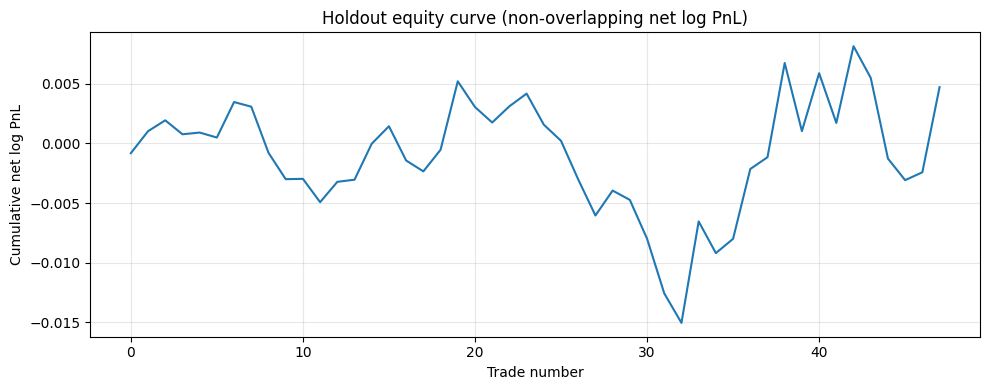

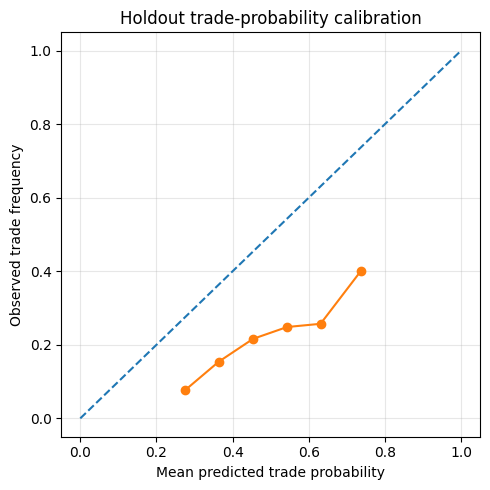

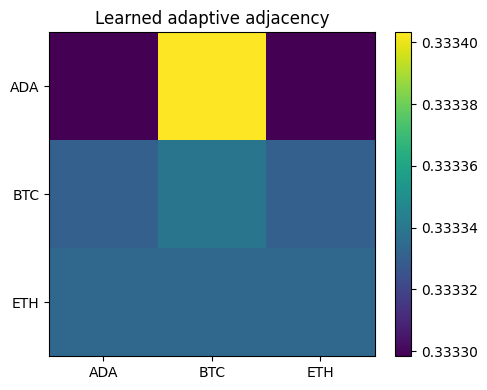

Support weights [static, prior, adaptive]: [0.33206633 0.33419007 0.3337436 ]


In [20]:
# Optional plots / diagnostics

if any([CFG["plot_equity_curve"], CFG["plot_trade_calibration"], CFG["plot_adaptive_adjacency"]]):
    import matplotlib.pyplot as plt

if bool(CFG["plot_equity_curve"]):
    eq = production_artifact["test_eval"]["equity_curve"]
    if len(eq) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(eq)
        plt.title("Holdout equity curve (non-overlapping net log PnL)")
        plt.xlabel("Trade number")
        plt.ylabel("Cumulative net log PnL")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if bool(CFG["plot_trade_calibration"]):
    p_trade = production_artifact["test_pred"]["p_trade"]
    y_trade_true = production_artifact["test_pred"]["y_trade_true"]
    bins = np.linspace(0.0, 1.0, 11)
    bin_ids = np.digitize(p_trade, bins) - 1

    xs, ys = [], []
    for b in range(len(bins) - 1):
        mask = bin_ids == b
        if int(mask.sum()) < 5:
            continue
        xs.append(float(p_trade[mask].mean()))
        ys.append(float(y_trade_true[mask].mean()))

    if xs:
        plt.figure(figsize=(5, 5))
        plt.plot([0, 1], [0, 1], "--")
        plt.plot(xs, ys, marker="o")
        plt.title("Holdout trade-probability calibration")
        plt.xlabel("Mean predicted trade probability")
        plt.ylabel("Observed trade frequency")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if bool(CFG["plot_adaptive_adjacency"]):
    a_adapt_np = production_artifact["graph_diag"]["adaptive_adj"]
    support_weights = production_artifact["graph_diag"]["support_weights"]

    plt.figure(figsize=(5, 4))
    plt.imshow(a_adapt_np, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(ASSETS)), ASSETS)
    plt.yticks(range(len(ASSETS)), ASSETS)
    plt.title("Learned adaptive adjacency")
    plt.tight_layout()
    plt.show()

    print("Support weights [static, prior, adaptive]:", support_weights)



In [21]:
# Final sanity checks

print("\n" + "=" * 100)
print("FINAL SANITY CHECKS")
print(f"Frequency: {CFG['freq']} | bar={DERIVED['bar_timedelta']}")
print(f"Forecast horizon: {HORIZON_BARS} bars = {CFG['forecast_horizon_minutes']} minutes")
print(f"Lookback: {LOOKBACK_BARS} bars = {CFG['lookback_minutes']} minutes")
print(f"Purge gap: {PURGE_GAP_BARS} bars")
print(f"Receptive field: {DERIVED['receptive_field_bars']} bars")
print(f"Coverage ratio RF/lookback: {DERIVED['receptive_field_bars'] / DERIVED['lookback_bars']:.3f}")
print(f"Temporal dilations used: {DERIVED['temporal_dilations']}")
print(f"Panel rows: {len(panel)}")
print(f"Usable samples: {len(ENTRY_BARS)}")
print(f"Pre-holdout samples: {len(PRE_HOLDOUT_POSITIONS)}")
print(f"Holdout samples: {len(HOLDOUT_POSITIONS)}")
print(f"Trade label ratio (all usable samples): {np.mean(TARGETS['y_trade'][ENTRY_BARS]):.4f}")
print("Beta direction convention: beta_src_to_dst = Cov(r_src, r_dst) / Var(r_src)")
print(
    f"Dropped unresolved lead-lag seconds at this frequency: {DERIVED['dropped_lead_lag_seconds']}"
)
print(
    f"Dropped too-short rolling-stat windows in bars: "
    f"corr/beta={DERIVED['dropped_corr_window_bars']}, "
    f"feature_vol={DERIVED['dropped_feature_vol_window_bars']}"
)
print(
    f"Production holdout trades: {production_artifact['test_eval']['n_trades']} | "
    f"trade_rate={production_artifact['test_eval']['trade_rate']:.4f} | "
    f"hit_rate={production_artifact['test_eval']['hit_rate']:.4f}"
)
print(
    f"Execution costs: spread crossing via midpoint +/- spread/2, "
    f"fee={CFG['fee_bps_one_way']} bps one-way"
)
print(f"Artifacts saved in: {ART_DIR.resolve()}")


FINAL SANITY CHECKS
Frequency: 1min | bar=0 days 00:01:00
Forecast horizon: 5 bars = 5 minutes
Lookback: 60 bars = 60 minutes
Purge gap: 5 bars
Receptive field: 60 bars
Coverage ratio RF/lookback: 1.000
Temporal dilations used: [1, 2, 4, 8, 16, 28]
Panel rows: 12882
Usable samples: 12817
Pre-holdout samples: 11530
Holdout samples: 1282
Trade label ratio (all usable samples): 0.1957
Beta direction convention: beta_src_to_dst = Cov(r_src, r_dst) / Var(r_src)
Dropped unresolved lead-lag seconds at this frequency: []
Dropped too-short rolling-stat windows in bars: corr/beta=[], feature_vol=[]
Production holdout trades: 48 | trade_rate=0.0374 | hit_rate=0.4792
Execution costs: spread crossing via midpoint +/- spread/2, fee=1.0 bps one-way
Artifacts saved in: /Users/vitalii/Desktop/Model_Market_Microstructure/Graph_Neural_Network_for_Market_Microstructure/TGNN2026/artifacts_stg_baseline_fixed5m_exactrf
